### Experimental Setup

In [1]:
FEATURE_SELECTION_METHOD = "PSO"
DEEP_LEARNING_CATEGORY = "Attention"
MODEL_ARCHITECTURE = "Transformer"
DATASET_NAME = "Pattern"

**Developed By:** eDySec Research Team   
**Plartform:** Ubuntu 

All experiments in this notebook were conducted using **Python 3.10** with the following libraries:

`pandas==1.5.3`,  
`scikit-learn==1.2.2`,  
`openpyxl`,  
`numpy==1.23.5`,  
`scipy==1.9.3`,  
`tensorflow==2.11.0`,  
`matplotlib==3.7.1`,  
`seaborn==0.12.2`,  
`joblib==1.3.2`,  
`shap==0.41.0`,  
`lime`,  
`flaml[automl]==2.5.0`,  
`notebook==6.5.6`,  
`pywinpty==2.0.10`  (Only for windows)  `threadpoolctl==3.1.0` (for Ubuntu)   
`terminado==0.17.1`,  
`transformers==4.49.0`.

#### Full Environment Setup: https://github.com/tanzirmehedi/eDySec

These versions were used to ensure **consistent and reproducible experimental results**.

### Import Necessary Packages

In [2]:
# ============================================================
# Standard Library
# ============================================================
import os
import gc
import sys
import time
import warnings

warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

# ============================================================
# Numerical and Data Processing
# ============================================================
import numpy as np
import pandas as pd
import scipy

# ============================================================
# Visualization
# ============================================================
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Scikit-learn
# ============================================================
import sklearn
from scipy.sparse import csr_matrix, hstack
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    auc,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ============================================================
# TensorFlow / Keras
# ============================================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau,
)
from tensorflow.keras.layers import (
    BatchNormalization,
    Dense,
    Dropout,
    LSTM,
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# ============================================================
# Transformers
# ============================================================
import transformers
from transformers import (
    BertTokenizer,
    GPT2Tokenizer,
    TFBertModel,
    TFGPT2Model,
)

# ============================================================
# AutoML and Model Persistence
# ============================================================
from flaml import AutoML
import joblib

### Version Checking

In [3]:
print("=" * 60)
print("Python Version")
print("=" * 60)
print(sys.version)

print("\n" + "=" * 60)
print("Core Library Versions")
print("=" * 60)
print(f"NumPy            : {np.__version__}")
print(f"Pandas           : {pd.__version__}")
print(f"Matplotlib       : {matplotlib.__version__}")
print(f"Seaborn          : {sns.__version__}")
print(f"SciPy            : {scipy.__version__}")
print(f"Scikit-learn     : {sklearn.__version__}")
print(f"TensorFlow       : {tf.__version__}")
print(f"Transformers     : {transformers.__version__}")
print(f"Joblib           : {joblib.__version__}")

print("\n" + "=" * 60)
print("Keras Version")
print("=" * 60)
print(f"Keras (tf.keras) : {tf.keras.__version__}")

print("\n" + "=" * 60)
print("CUDA / GPU Info")
print("=" * 60)
print(f"Built with CUDA  : {tf.test.is_built_with_cuda()}")
print(f"GPU Available    : {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"GPUs             : {tf.config.list_physical_devices('GPU')}")

Python Version
3.10.20 (main, Mar 11 2026, 17:46:40) [GCC 14.3.0]

Core Library Versions
NumPy            : 1.23.5
Pandas           : 1.5.3
Matplotlib       : 3.7.1
Seaborn          : 0.12.2
SciPy            : 1.9.3
Scikit-learn     : 1.2.2
TensorFlow       : 2.11.0
Transformers     : 4.38.2
Joblib           : 1.3.2

Keras Version
Keras (tf.keras) : 2.11.0

CUDA / GPU Info
Built with CUDA  : True
GPU Available    : True
GPUs             : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### GPU Checking

In [4]:
# ============================================================
# GPU Status and Resource Monitoring
# ============================================================

# Display NVIDIA GPU information including driver version,
# CUDA version, memory usage, and active processes

!nvidia-smi

/bin/bash: /home/n11894571/miniconda3/envs/tf211gpu/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Tue Apr  7 13:11:57 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.54                 Driver Version: 595.79         CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A6000               On  |   00000000:01:00.0  On |                  Off |
| 30%   29C    P8             13W /  300W |     456MiB /  49140MiB |     18%      Default |
|           

### GPU Status Checking

In [5]:
# ============================================================
# Detailed System and GPU Diagnostics
# ============================================================

print("=" * 60)
print("TensorFlow Environment Diagnostics")
print("=" * 60)

print(f"Conda Prefix        : {os.environ.get('CONDA_PREFIX')}")
print(f"LD_LIBRARY_PATH     : {os.environ.get('LD_LIBRARY_PATH')}")
print(f"TensorFlow Version  : {tf.__version__}")
print(f"Built with CUDA     : {tf.test.is_built_with_cuda()}")

gpus = tf.config.list_physical_devices('GPU')
print(f"Number of GPUs      : {len(gpus)}")

for idx, gpu in enumerate(gpus):
    print(f"GPU {idx}            : {gpu}")

print("=" * 60)

TensorFlow Environment Diagnostics
Conda Prefix        : /home/n11894571/miniconda3/envs/tf211gpu
LD_LIBRARY_PATH     : /home/n11894571/miniconda3/envs/tf211gpu/lib:
TensorFlow Version  : 2.11.0
Built with CUDA     : True
Number of GPUs      : 1
GPU 0            : PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


### Allocate as Much GPU Memory as Needed

In [6]:
# ============================================================
# Advanced GPU Configuration and Diagnostics
# ============================================================

gpus = tf.config.list_physical_devices('GPU')

print("=" * 60)
print("GPU Configuration")
print("=" * 60)

if gpus:
    print(f"Number of GPUs detected: {len(gpus)}")
    
    try:
        for idx, gpu in enumerate(gpus):
            # Disable memory growth (allocate full GPU memory)
            tf.config.experimental.set_memory_growth(gpu, False)
            print(f"GPU {idx}: Memory growth disabled (full allocation mode)")
    
    except RuntimeError as e:
        print(f"RuntimeError: {e}")
else:
    print("No GPU detected. Using CPU.")

print("=" * 60)

GPU Configuration
Number of GPUs detected: 1
GPU 0: Memory growth disabled (full allocation mode)


### Load QUT-DV25 Dataset

In [7]:
# ============================================================
# Data Loading and Initial Inspection
# ============================================================

# Define the dataset file path
file_path = 'QUT-DV25_'+DATASET_NAME+'_Traces.csv'

# Load the dataset into a pandas DataFrame
data = pd.read_csv(file_path)

# Display the first few rows for initial inspection
data.head()

,Package_Name,Pattern_1,Pattern_2,Pattern_3,Pattern_4,Pattern_5,Pattern_6,Pattern_7,Pattern_8,Pattern_9,Pattern_10,Level
0,10Cent10-999.0.4.tar.gz,newfstatat -> newfstatat -> newfstatat,fstat -> ioctl -> lseek,openat -> fstat -> ioctl,newfstatat -> newfstatat -> openat,newfstatat -> openat -> fstat,newfstatat -> newfstatat -> newfstatat -> no-e...,fstat -> ioctl -> lseek -> no-error -> no-fd,openat -> fstat -> ioctl -> no-error -> no-fd,ioctl -> lseek -> lseek -> error=ENOTTY -> no-fd,read -> read -> close -> no-error -> no-fd,1
1,10Cent11-999.0.4.tar.gz,newfstatat -> newfstatat -> newfstatat,read -> read -> read,newfstatat -> openat -> fstat,ioctl -> ioctl -> ioctl,newfstatat -> newfstatat -> openat,newfstatat -> newfstatat -> newfstatat -> no-e...,read -> read -> read -> no-error -> no-fd,newfstatat -> openat -> fstat -> no-error -> n...,ioctl -> ioctl -> ioctl -> no-error -> no-fd,fcntl -> fstat -> fcntl -> no-error -> no-fd,1
2,11Cent-999.0.0.tar.gz,newfstatat -> newfstatat -> newfstatat,newfstatat -> newfstatat -> openat,read -> read -> read,newfstatat -> openat -> fstat,fstat -> ioctl -> lseek,newfstatat -> newfstatat -> newfstatat -> no-e...,newfstatat -> newfstatat -> openat -> no-error...,read -> read -> read -> no-error -> no-fd,openat -> fstat -> ioctl -> no-error -> no-fd,newfstatat -> openat -> fstat -> no-error -> n...,1
3,11Cent-999.0.1.tar.gz,newfstatat -> newfstatat -> newfstatat,read -> read -> read,newfstatat -> openat -> fstat,openat -> fstat -> fcntl,fstat -> fcntl -> fstat,newfstatat -> newfstatat -> newfstatat -> no-e...,read -> read -> read -> no-error -> no-fd,newfstatat -> openat -> fstat -> no-error -> n...,openat -> fstat -> fcntl -> no-error -> no-fd,fstat -> fcntl -> fstat -> no-error -> no-fd,1
4,11Cent-999.0.2.tar.gz,newfstatat -> newfstatat -> newfstatat,read -> read -> read,newfstatat -> openat -> fstat,read -> poll -> read,poll -> read -> read,newfstatat -> newfstatat -> newfstatat -> no-e...,read -> read -> read -> no-error -> no-fd,newfstatat -> openat -> fstat -> no-error -> n...,read -> poll -> read -> error=EAGAIN -> no-fd,newfstatat -> newfstatat -> openat -> no-error...,1


### Clear Backend Session

In [8]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Selected Features

In [9]:
selected_features = ['Pattern_1', 'Pattern_4', 'Pattern_5', 'Pattern_9', 'Pattern_10']

### Data Preprocessing

In [10]:
# ============================================================
# Feature Selection and Dataset Preparation
# ============================================================

# Select the predefined feature subset
selected_features_with_target = selected_features.copy()

# Create a feature matrix from the selected features
X = data[selected_features_with_target].copy()

# Define the target variable
y = data['Level']

# ============================================================
# Train–Validation–Test Split (70%–15%–15%)
# ============================================================

# Step 1: Split into training (70%) and temporary set (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Step 2: Split temporary set into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

# ============================================================
# Dataset Summary
# ============================================================

print(f"Training set shape     : {X_train.shape}")
print(f"Validation set shape   : {X_val.shape}")
print(f"Test set shape         : {X_test.shape}")

Training set shape     : (9989, 5)
Validation set shape   : (2141, 5)
Test set shape         : (2141, 5)


### Setup OUTPUT_DIR

In [11]:
OUTPUT_DIR = "Evaluation_Outputs_"+DATASET_NAME+"_"+FEATURE_SELECTION_METHOD+"_"+DEEP_LEARNING_CATEGORY+"_"+MODEL_ARCHITECTURE
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUTPUT_DIR

'Evaluation_Outputs_Pattern_PSO_Attention_Transformer'

### Model

In [12]:
# ============================================================
# Define model saving configuration
# ============================================================

SAVE_DIR = OUTPUT_DIR
MODEL_NAME = os.path.join(SAVE_DIR, OUTPUT_DIR + ".h5")


# ============================================================
# Convert each row into a single text string
# ============================================================
def row_to_text(df):
    texts = []
    for _, row in df.iterrows():
        parts = []
        for col in df.columns:
            value = row[col]
            parts.append(f"{col}: {value}")
        texts.append(" [SEP] ".join(parts))
    return texts


train_texts = row_to_text(X_train)
val_texts   = row_to_text(X_val)
test_texts  = row_to_text(X_test)


# ============================================================
# Tokenization
# ============================================================
max_words = 25
max_len = 30

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(train_texts)

X_train_seq = tokenizer.texts_to_sequences(train_texts)
X_val_seq   = tokenizer.texts_to_sequences(val_texts)
X_test_seq  = tokenizer.texts_to_sequences(test_texts)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")


# ============================================================
# Labels
# ============================================================
y_train = np.asarray(y_train).astype(np.float32)
y_val   = np.asarray(y_val).astype(np.float32)
y_test  = np.asarray(y_test).astype(np.float32)


# ============================================================
# Callbacks
# ============================================================
checkpoint_cb = ModelCheckpoint(
    MODEL_NAME,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

reduce_lr_cb = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=200,
    verbose=1
)

early_stop_cb = EarlyStopping(
    monitor="val_loss",
    patience=200,
    restore_best_weights=True,
    verbose=1
)


# ============================================================
# Transformer block
# ============================================================
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.2, l2_reg=1e-4):
        super().__init__()
        self.att = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=rate
        )
        self.ffn = models.Sequential([
            layers.Dense(
                ff_dim,
                activation="relu",
                kernel_regularizer=regularizers.l2(l2_reg)
            ),
            layers.Dropout(rate),
            layers.Dense(
                embed_dim,
                kernel_regularizer=regularizers.l2(l2_reg)
            )
        ])
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, inputs, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1, training=training)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)


# ============================================================
# Token + Position Embedding
# ============================================================
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, max_len, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=max_len, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions


# ============================================================
# Build Transformer text classifier
# ============================================================
vocab_size = min(max_words, len(tokenizer.word_index) + 1)
embed_dim = 128
num_heads = 4
ff_dim = 256
num_blocks = 2
dropout_rate = 0.2
l2_reg = 1e-4

inputs = layers.Input(shape=(max_len,), dtype="int32")

x = TokenAndPositionEmbedding(max_len, vocab_size, embed_dim)(inputs)

for _ in range(num_blocks):
    x = TransformerBlock(
        embed_dim=embed_dim,
        num_heads=num_heads,
        ff_dim=ff_dim,
        rate=dropout_rate,
        l2_reg=l2_reg
    )(x)

x = layers.GlobalAveragePooling1D()(x)
x = layers.Dense(128, activation="relu", kernel_regularizer=regularizers.l2(l2_reg))(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(l2_reg))(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs=inputs, outputs=outputs)


# ============================================================
# Compile model
# ============================================================
model.compile(
    optimizer=tf.keras.optimizers.legacy.Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 30)]              0         
                                                                 
 token_and_position_embeddin  (None, 30, 128)          7040      
 g (TokenAndPositionEmbeddin                                     
 g)                                                              
                                                                 
 transformer_block (Transfor  (None, 30, 128)          132480    
 merBlock)                                                       
                                                                 
 transformer_block_1 (Transf  (None, 30, 128)          132480    
 ormerBlock)                                                     
                                                                 
 global_average_pooling1d (G  (None, 128)              0     

### Compime the Model

In [13]:
# ==========================
# Train model
# ==========================

start_train = time.time()

history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=200,
    batch_size=16,
    callbacks=[checkpoint_cb, reduce_lr_cb, early_stop_cb],
    verbose=1
)

end_train = time.time()
training_time = end_train - start_train

Epoch 1/200
623/625 [============================>.] - ETA: 0s - loss: 0.6237 - accuracy: 0.7184
Epoch 1: val_accuracy improved from -inf to 0.78608, saving model to Evaluation_Outputs_Pattern_PSO_Attention_Transformer/Evaluation_Outputs_Pattern_PSO_Attention_Transformer.h5
625/625 [==============================] - 9s 12ms/step - loss: 0.6233 - accuracy: 0.7185 - val_loss: 0.5351 - val_accuracy: 0.7861 - lr: 3.0000e-04
Epoch 2/200
623/625 [============================>.] - ETA: 0s - loss: 0.5401 - accuracy: 0.7802
Epoch 2: val_accuracy improved from 0.78608 to 0.79916, saving model to Evaluation_Outputs_Pattern_PSO_Attention_Transformer/Evaluation_Outputs_Pattern_PSO_Attention_Transformer.h5
625/625 [==============================] - 7s 12ms/step - loss: 0.5400 - accuracy: 0.7805 - val_loss: 0.5376 - val_accuracy: 0.7992 - lr: 3.0000e-04
Epoch 3/200
623/625 [============================>.] - ETA: 0s - loss: 0.5217 - accuracy: 0.7811
Epoch 3: val_accuracy did not improve from 0.79916
6

625/625 [==============================] - 8s 12ms/step - loss: 0.3992 - accuracy: 0.8206 - val_loss: 0.4110 - val_accuracy: 0.8239 - lr: 3.0000e-04
Epoch 26/200
625/625 [==============================] - ETA: 0s - loss: 0.3971 - accuracy: 0.8230
Epoch 26: val_accuracy did not improve from 0.82858
625/625 [==============================] - 7s 12ms/step - loss: 0.3971 - accuracy: 0.8230 - val_loss: 0.4093 - val_accuracy: 0.8258 - lr: 3.0000e-04
Epoch 27/200
624/625 [============================>.] - ETA: 0s - loss: 0.3982 - accuracy: 0.8239
Epoch 27: val_accuracy did not improve from 0.82858
625/625 [==============================] - 8s 12ms/step - loss: 0.3982 - accuracy: 0.8240 - val_loss: 0.4252 - val_accuracy: 0.8155 - lr: 3.0000e-04
Epoch 28/200
624/625 [============================>.] - ETA: 0s - loss: 0.3939 - accuracy: 0.8262
Epoch 28: val_accuracy did not improve from 0.82858
625/625 [==============================] - 7s 12ms/step - loss: 0.3942 - accuracy: 0.8260 - val_loss: 0

625/625 [==============================] - 7s 12ms/step - loss: 0.3730 - accuracy: 0.8295 - val_loss: 0.3918 - val_accuracy: 0.8319 - lr: 3.0000e-04
Epoch 53/200
622/625 [============================>.] - ETA: 0s - loss: 0.3726 - accuracy: 0.8311
Epoch 53: val_accuracy did not improve from 0.83512
625/625 [==============================] - 7s 12ms/step - loss: 0.3726 - accuracy: 0.8311 - val_loss: 0.3890 - val_accuracy: 0.8342 - lr: 3.0000e-04
Epoch 54/200
623/625 [============================>.] - ETA: 0s - loss: 0.3740 - accuracy: 0.8316
Epoch 54: val_accuracy did not improve from 0.83512
625/625 [==============================] - 7s 11ms/step - loss: 0.3736 - accuracy: 0.8318 - val_loss: 0.3974 - val_accuracy: 0.8333 - lr: 3.0000e-04
Epoch 55/200
625/625 [==============================] - ETA: 0s - loss: 0.3729 - accuracy: 0.8306
Epoch 55: val_accuracy did not improve from 0.83512
625/625 [==============================] - 7s 12ms/step - loss: 0.3729 - accuracy: 0.8306 - val_loss: 0

625/625 [==============================] - 7s 11ms/step - loss: 0.3651 - accuracy: 0.8321 - val_loss: 0.3860 - val_accuracy: 0.8342 - lr: 3.0000e-04
Epoch 80/200
623/625 [============================>.] - ETA: 0s - loss: 0.3624 - accuracy: 0.8371
Epoch 80: val_accuracy did not improve from 0.83652
625/625 [==============================] - 7s 11ms/step - loss: 0.3631 - accuracy: 0.8366 - val_loss: 0.3899 - val_accuracy: 0.8351 - lr: 3.0000e-04
Epoch 81/200
623/625 [============================>.] - ETA: 0s - loss: 0.3635 - accuracy: 0.8350
Epoch 81: val_accuracy did not improve from 0.83652
625/625 [==============================] - 7s 11ms/step - loss: 0.3636 - accuracy: 0.8347 - val_loss: 0.3884 - val_accuracy: 0.8277 - lr: 3.0000e-04
Epoch 82/200
621/625 [============================>.] - ETA: 0s - loss: 0.3628 - accuracy: 0.8307
Epoch 82: val_accuracy did not improve from 0.83652
625/625 [==============================] - 7s 11ms/step - loss: 0.3630 - accuracy: 0.8307 - val_loss: 0

Epoch 106/200
624/625 [============================>.] - ETA: 0s - loss: 0.3599 - accuracy: 0.8363
Epoch 106: val_accuracy did not improve from 0.83839
625/625 [==============================] - 7s 11ms/step - loss: 0.3599 - accuracy: 0.8364 - val_loss: 0.3838 - val_accuracy: 0.8333 - lr: 3.0000e-04
Epoch 107/200
623/625 [============================>.] - ETA: 0s - loss: 0.3588 - accuracy: 0.8375
Epoch 107: val_accuracy did not improve from 0.83839
625/625 [==============================] - 7s 11ms/step - loss: 0.3588 - accuracy: 0.8374 - val_loss: 0.4020 - val_accuracy: 0.8323 - lr: 3.0000e-04
Epoch 108/200
624/625 [============================>.] - ETA: 0s - loss: 0.3574 - accuracy: 0.8372
Epoch 108: val_accuracy did not improve from 0.83839
625/625 [==============================] - 7s 11ms/step - loss: 0.3573 - accuracy: 0.8372 - val_loss: 0.3787 - val_accuracy: 0.8384 - lr: 3.0000e-04
Epoch 109/200
623/625 [============================>.] - ETA: 0s - loss: 0.3532 - accuracy: 0.837

Epoch 133/200
625/625 [==============================] - ETA: 0s - loss: 0.3485 - accuracy: 0.8381
Epoch 133: val_accuracy did not improve from 0.84026
625/625 [==============================] - 8s 12ms/step - loss: 0.3485 - accuracy: 0.8381 - val_loss: 0.3929 - val_accuracy: 0.8379 - lr: 3.0000e-04
Epoch 134/200
621/625 [============================>.] - ETA: 0s - loss: 0.3547 - accuracy: 0.8388
Epoch 134: val_accuracy did not improve from 0.84026
625/625 [==============================] - 7s 12ms/step - loss: 0.3544 - accuracy: 0.8390 - val_loss: 0.3980 - val_accuracy: 0.8351 - lr: 3.0000e-04
Epoch 135/200
624/625 [============================>.] - ETA: 0s - loss: 0.3519 - accuracy: 0.8374
Epoch 135: val_accuracy did not improve from 0.84026
625/625 [==============================] - 8s 12ms/step - loss: 0.3518 - accuracy: 0.8375 - val_loss: 0.3919 - val_accuracy: 0.8300 - lr: 3.0000e-04
Epoch 136/200
621/625 [============================>.] - ETA: 0s - loss: 0.3520 - accuracy: 0.838

622/625 [============================>.] - ETA: 0s - loss: 0.3491 - accuracy: 0.8404
Epoch 160: val_accuracy did not improve from 0.84026
625/625 [==============================] - 7s 11ms/step - loss: 0.3489 - accuracy: 0.8405 - val_loss: 0.3894 - val_accuracy: 0.8398 - lr: 3.0000e-04
Epoch 161/200
620/625 [============================>.] - ETA: 0s - loss: 0.3476 - accuracy: 0.8419
Epoch 161: val_accuracy did not improve from 0.84026
625/625 [==============================] - 7s 11ms/step - loss: 0.3473 - accuracy: 0.8423 - val_loss: 0.4000 - val_accuracy: 0.8351 - lr: 3.0000e-04
Epoch 162/200
624/625 [============================>.] - ETA: 0s - loss: 0.3489 - accuracy: 0.8386
Epoch 162: val_accuracy did not improve from 0.84026
625/625 [==============================] - 7s 11ms/step - loss: 0.3490 - accuracy: 0.8386 - val_loss: 0.3965 - val_accuracy: 0.8356 - lr: 3.0000e-04
Epoch 163/200
623/625 [============================>.] - ETA: 0s - loss: 0.3441 - accuracy: 0.8371
Epoch 163: v

624/625 [============================>.] - ETA: 0s - loss: 0.3478 - accuracy: 0.8415
Epoch 187: val_accuracy did not improve from 0.84026
625/625 [==============================] - 8s 12ms/step - loss: 0.3481 - accuracy: 0.8414 - val_loss: 0.3972 - val_accuracy: 0.8393 - lr: 3.0000e-04
Epoch 188/200
624/625 [============================>.] - ETA: 0s - loss: 0.3477 - accuracy: 0.8394
Epoch 188: val_accuracy improved from 0.84026 to 0.84120, saving model to Evaluation_Outputs_Pattern_PSO_Attention_Transformer/Evaluation_Outputs_Pattern_PSO_Attention_Transformer.h5
625/625 [==============================] - 8s 12ms/step - loss: 0.3477 - accuracy: 0.8395 - val_loss: 0.3822 - val_accuracy: 0.8412 - lr: 3.0000e-04
Epoch 189/200
625/625 [==============================] - ETA: 0s - loss: 0.3467 - accuracy: 0.8407
Epoch 189: val_accuracy did not improve from 0.84120
625/625 [==============================] - 8s 12ms/step - loss: 0.3467 - accuracy: 0.8407 - val_loss: 0.3871 - val_accuracy: 0.840

### Clear Backend Session

In [14]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()

### Model Validation

In [15]:
# ==========================
# Validation Evaluation
# ==========================

start_val = time.time()
val_loss, val_acc = model.evaluate(X_val_pad, y_val, verbose=0)
end_val = time.time()
validation_time = end_val - start_val


# ==========================
# Test Evaluation
# ==========================

start_test = time.time()
test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
end_test = time.time()
testing_time = end_test - start_test


# ==========================
# Print Results
# ==========================

print(f"\nTraining Time: {training_time:.2f} seconds")
print(f"Validation Time: {validation_time:.2f} seconds")
print(f"Testing Time: {testing_time:.2f} seconds")

print(f"\nValidation Accuracy: {val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Training Time: 1450.80 seconds
Validation Time: 0.95 seconds
Testing Time: 0.39 seconds

Validation Accuracy: 0.8398
Test Accuracy: 0.8445


### Save Training Log

In [16]:
# Convert history to DataFrame
df = pd.DataFrame(history.history)

# Add epoch column (starting from 1)
df.insert(0, "epoch", range(1, len(df) + 1))

# Optional: round values for cleaner output
df = df.round(6)

# Define save path
training_log_path = os.path.join(
    OUTPUT_DIR,
    "training_log.xlsx"
)

# Save file
df.to_excel(training_log_path, index=False)

# Confirmation
print(f"Training log saved at: {training_log_path}")

# Preview
df.head()

Training log saved at: Evaluation_Outputs_Pattern_PSO_Attention_Transformer/training_log.xlsx


,epoch,loss,accuracy,val_loss,val_accuracy,lr
0,1,0.623349,0.718490,0.535128,0.786081,0.0003
1,2,0.539976,0.780459,0.537573,0.799159,0.0003
2,3,0.521615,0.781159,0.523504,0.788884,0.0003
3,4,0.507456,0.791871,0.486889,0.808968,0.0003
4,5,0.492986,0.798779,0.478681,0.812704,0.0003


### Trainig and Validation Plot

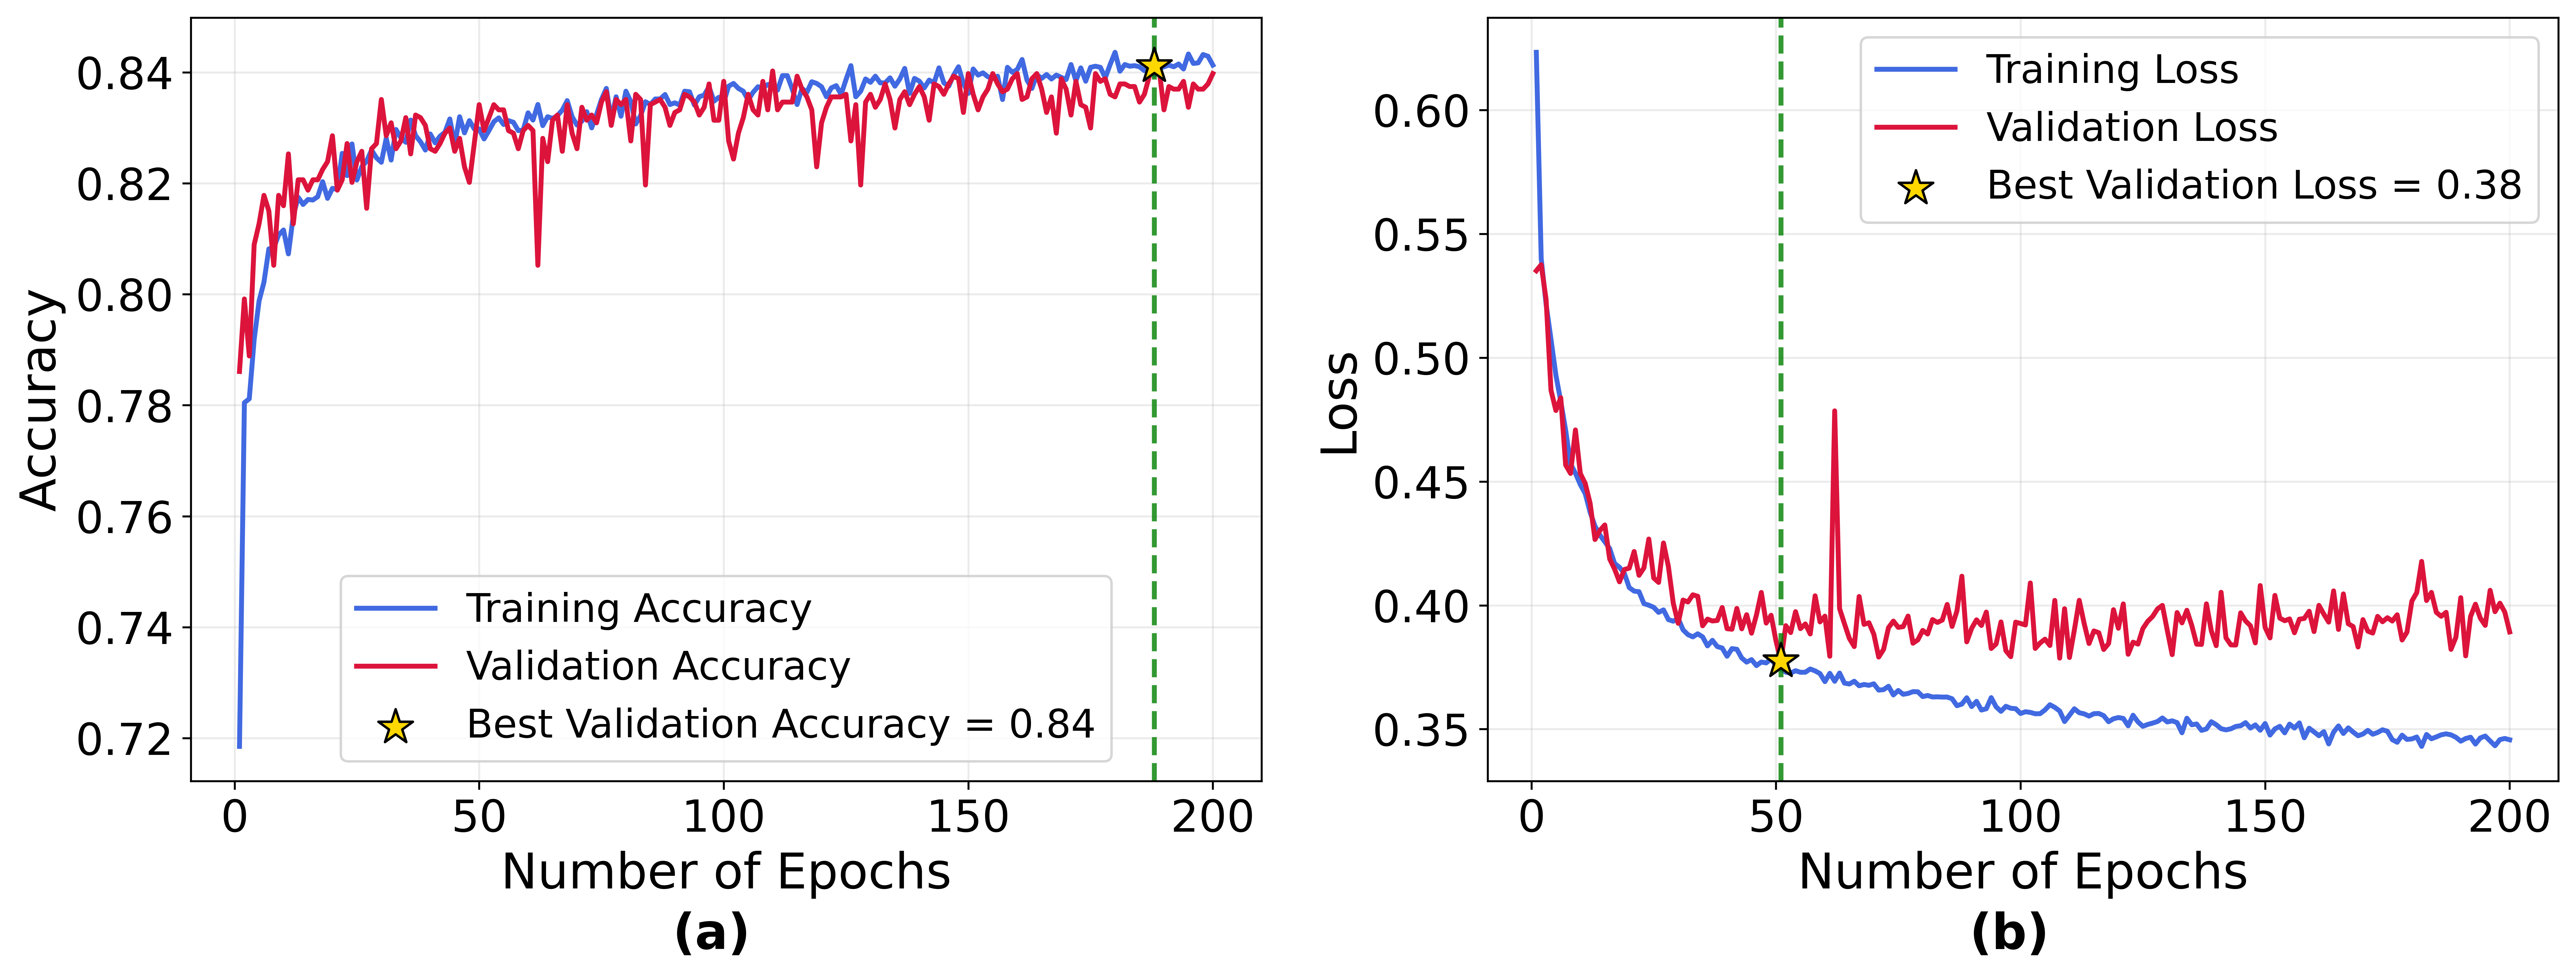

In [17]:
# ============================================================
# Font Settings
# ============================================================
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 16
})

# ============================================================
# Identify Best Epochs
# ============================================================

if "epoch" not in df.columns:
    df["epoch"] = range(1, len(df) + 1)

best_acc_idx = df["val_accuracy"].idxmax()
best_acc_epoch = int(df.loc[best_acc_idx, "epoch"])
best_acc = float(df.loc[best_acc_idx, "val_accuracy"])

best_loss_idx = df["val_loss"].idxmin()
best_loss_epoch = int(df.loc[best_loss_idx, "epoch"])
best_loss = float(df.loc[best_loss_idx, "val_loss"])

# ============================================================
# Combined Learning Curves
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=600)

# ============================================================
# Accuracy Plot
# ============================================================
ax1.plot(df["epoch"], df["accuracy"], linewidth=2,
         color="royalblue", label="Training Accuracy")

ax1.plot(df["epoch"], df["val_accuracy"], linewidth=2,
         color="crimson", label="Validation Accuracy")

ax1.axvline(best_acc_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax1.scatter(best_acc_epoch, best_acc,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Accuracy = {best_acc:.2f}")

ax1.set_xlabel("Number of Epochs")
ax1.set_ylabel("Accuracy")
ax1.grid(True, alpha=0.25)
ax1.legend(frameon=True)

# Accuracy plot ticks
for tick, label in zip(ax1.get_xticks(), ax1.get_xticklabels()):
    if int(tick) == best_acc_epoch:
        label.set_fontweight("bold")
        label.set_color("green")
        
# ============================================================
# Loss Plot
# ============================================================
ax2.plot(df["epoch"], df["loss"], linewidth=2,
         color="royalblue", label="Training Loss")

ax2.plot(df["epoch"], df["val_loss"], linewidth=2,
         color="crimson", label="Validation Loss")

ax2.axvline(best_loss_epoch,
            linestyle="--",
            linewidth=2,
            color="green",
            alpha=0.8)

ax2.scatter(best_loss_epoch, best_loss,
            s=220, marker="*", color="gold", edgecolor="black",
            zorder=3,
            label=f"Best Validation Loss = {best_loss:.2f}")

ax2.set_xlabel("Number of Epochs")
ax2.set_ylabel("Loss")
ax2.grid(True, alpha=0.25)
ax2.legend(frameon=True)

# Loss plot ticks
for tick, label in zip(ax2.get_xticks(), ax2.get_xticklabels()):
    if int(tick) == best_loss_epoch:
        label.set_fontweight("bold")
        label.set_color("green")
        
# ============================================================
# Panel Labels
# ============================================================
ax1.text(0.45, -0.22, "(a)", transform=ax1.transAxes,
         fontsize=20, fontweight="bold")

ax2.text(0.45, -0.22, "(b)", transform=ax2.transAxes,
         fontsize=20, fontweight="bold")

# ============================================================
# Final layout
# ============================================================
fig.tight_layout()

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.png"),
            dpi=600, bbox_inches="tight")

fig.savefig(os.path.join(OUTPUT_DIR, "learning_curves.pdf"),
            bbox_inches="tight")

plt.show()

### Classification Report


Evaluation Results: Train
Accuracy  : 0.845830
Precision : 0.859496
Recall    : 0.826418
F1-score  : 0.842632
ROC AUC   : 0.931865
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.833205  0.865200  0.848901      5000
         1.0   0.859496  0.826418  0.842632      4989

    accuracy                       0.845830      9989
   macro avg   0.846350  0.845809  0.845767      9989
weighted avg   0.846336  0.845830  0.845770      9989



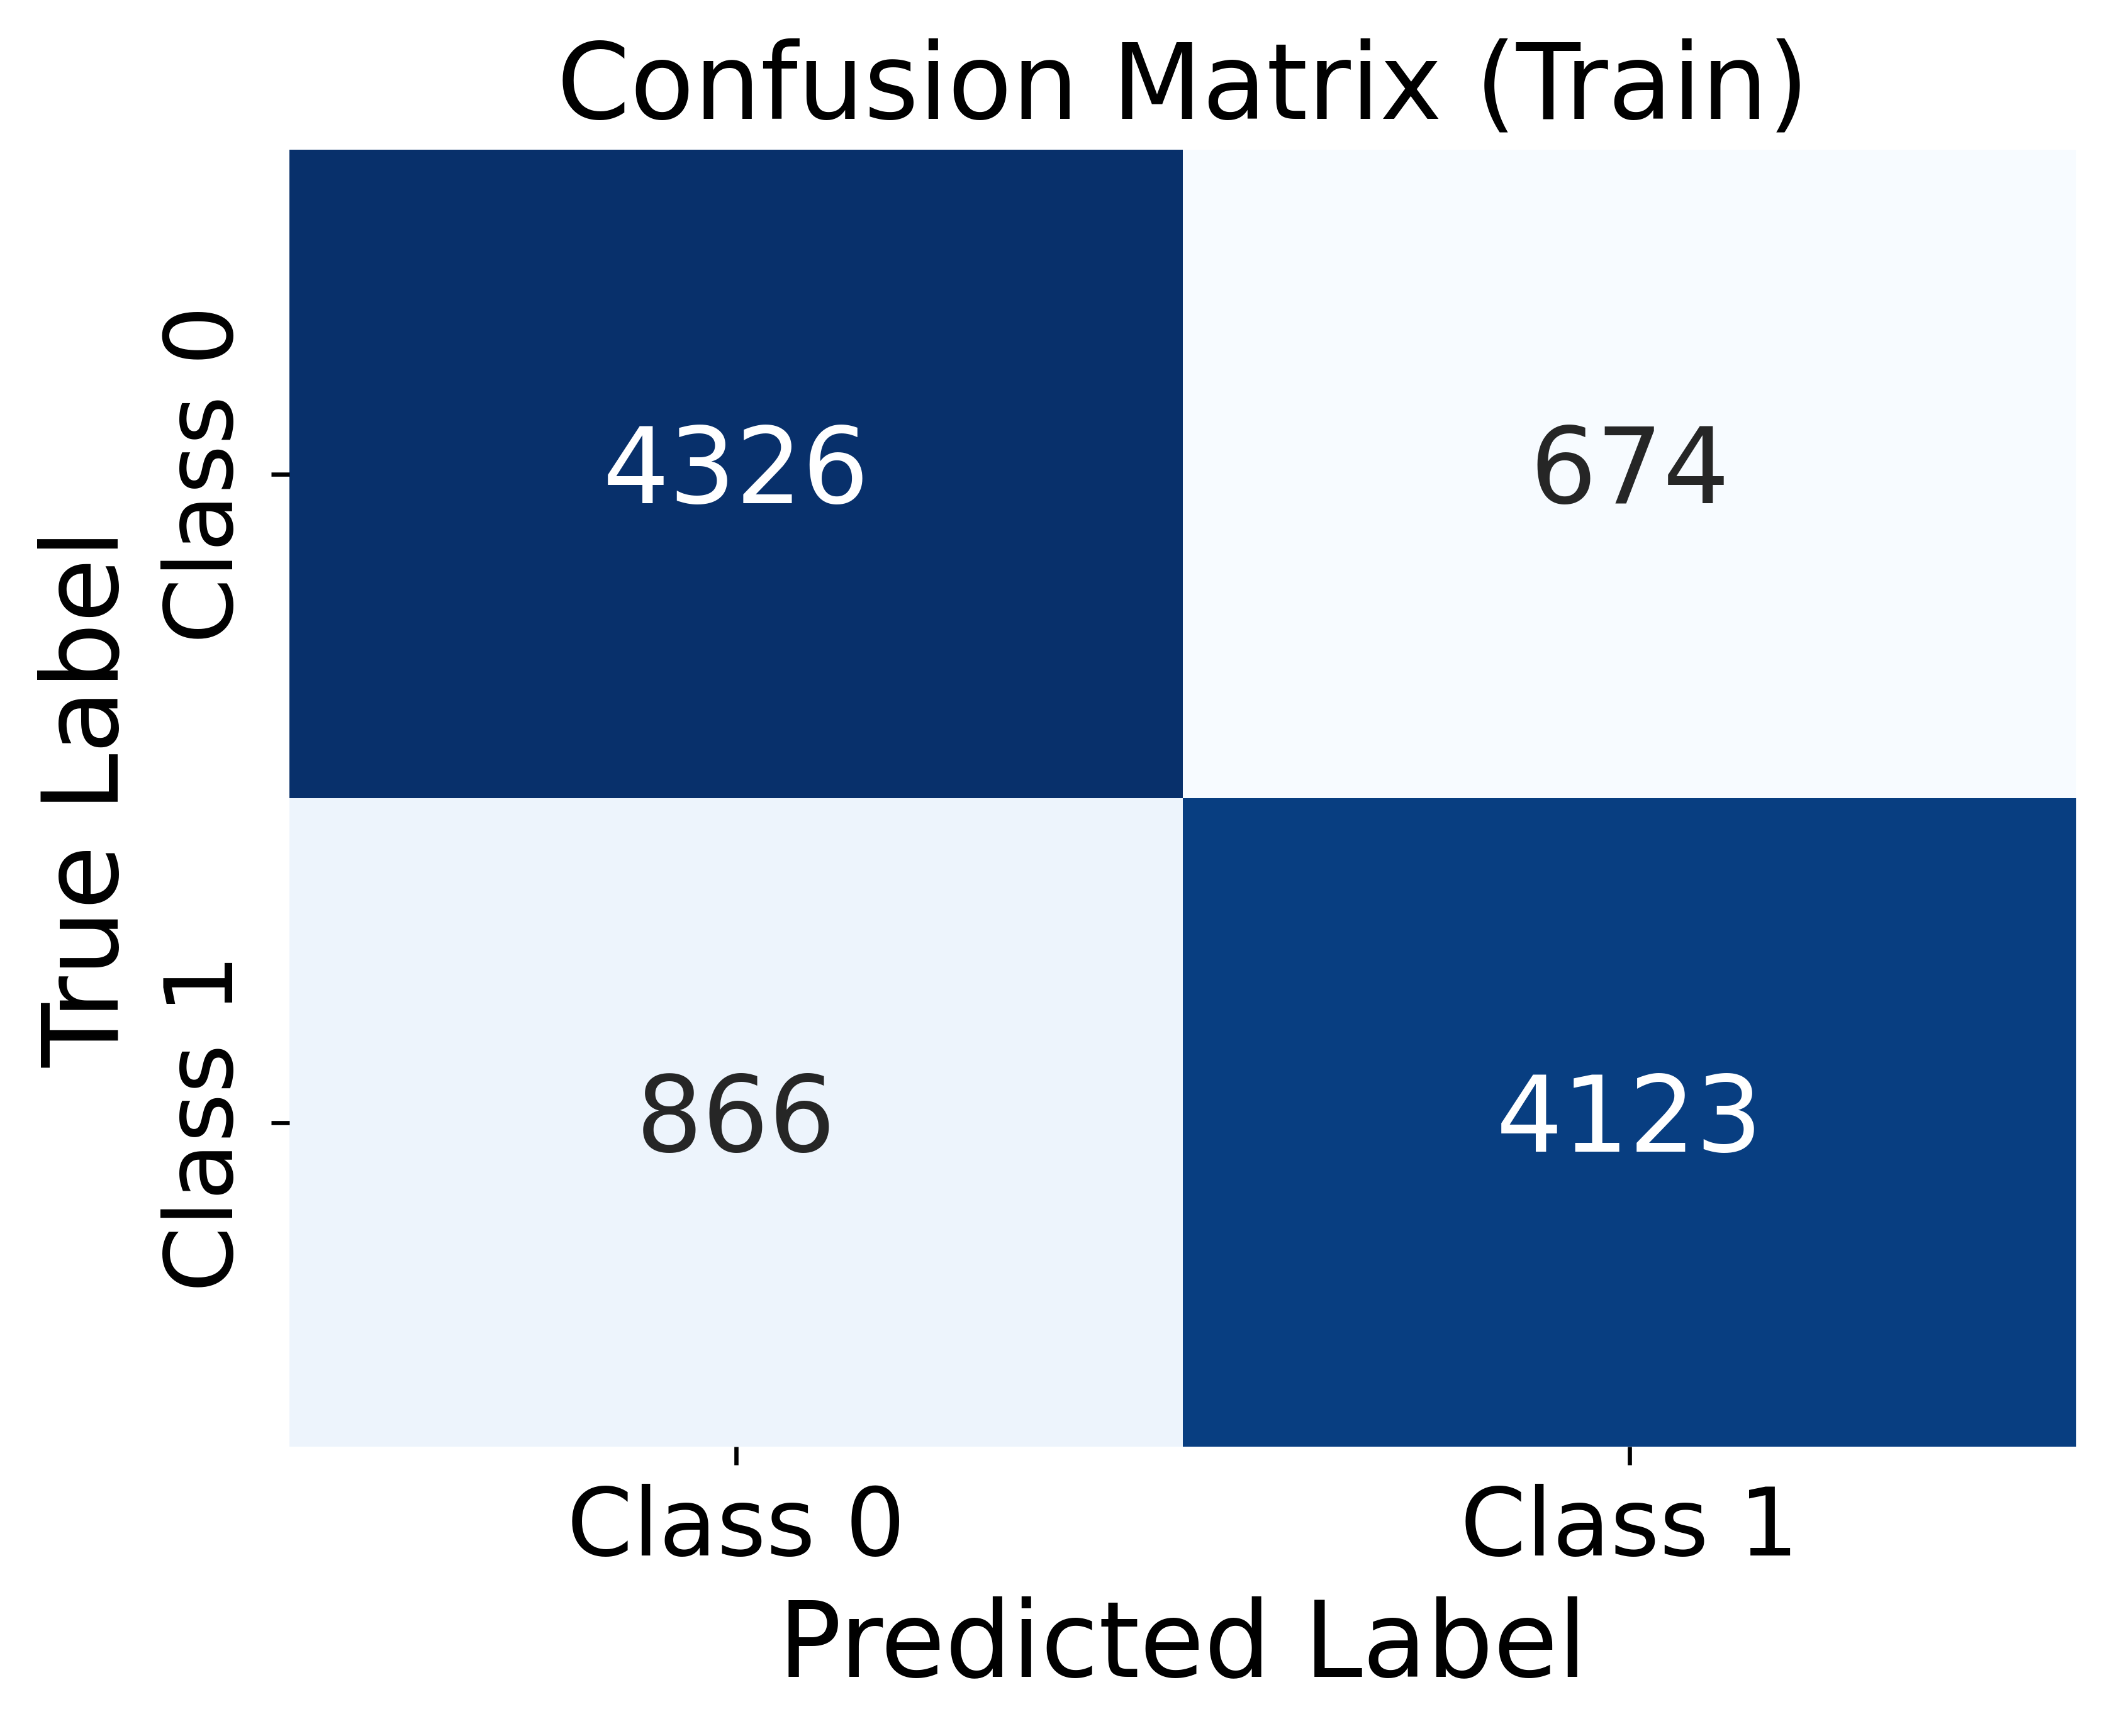

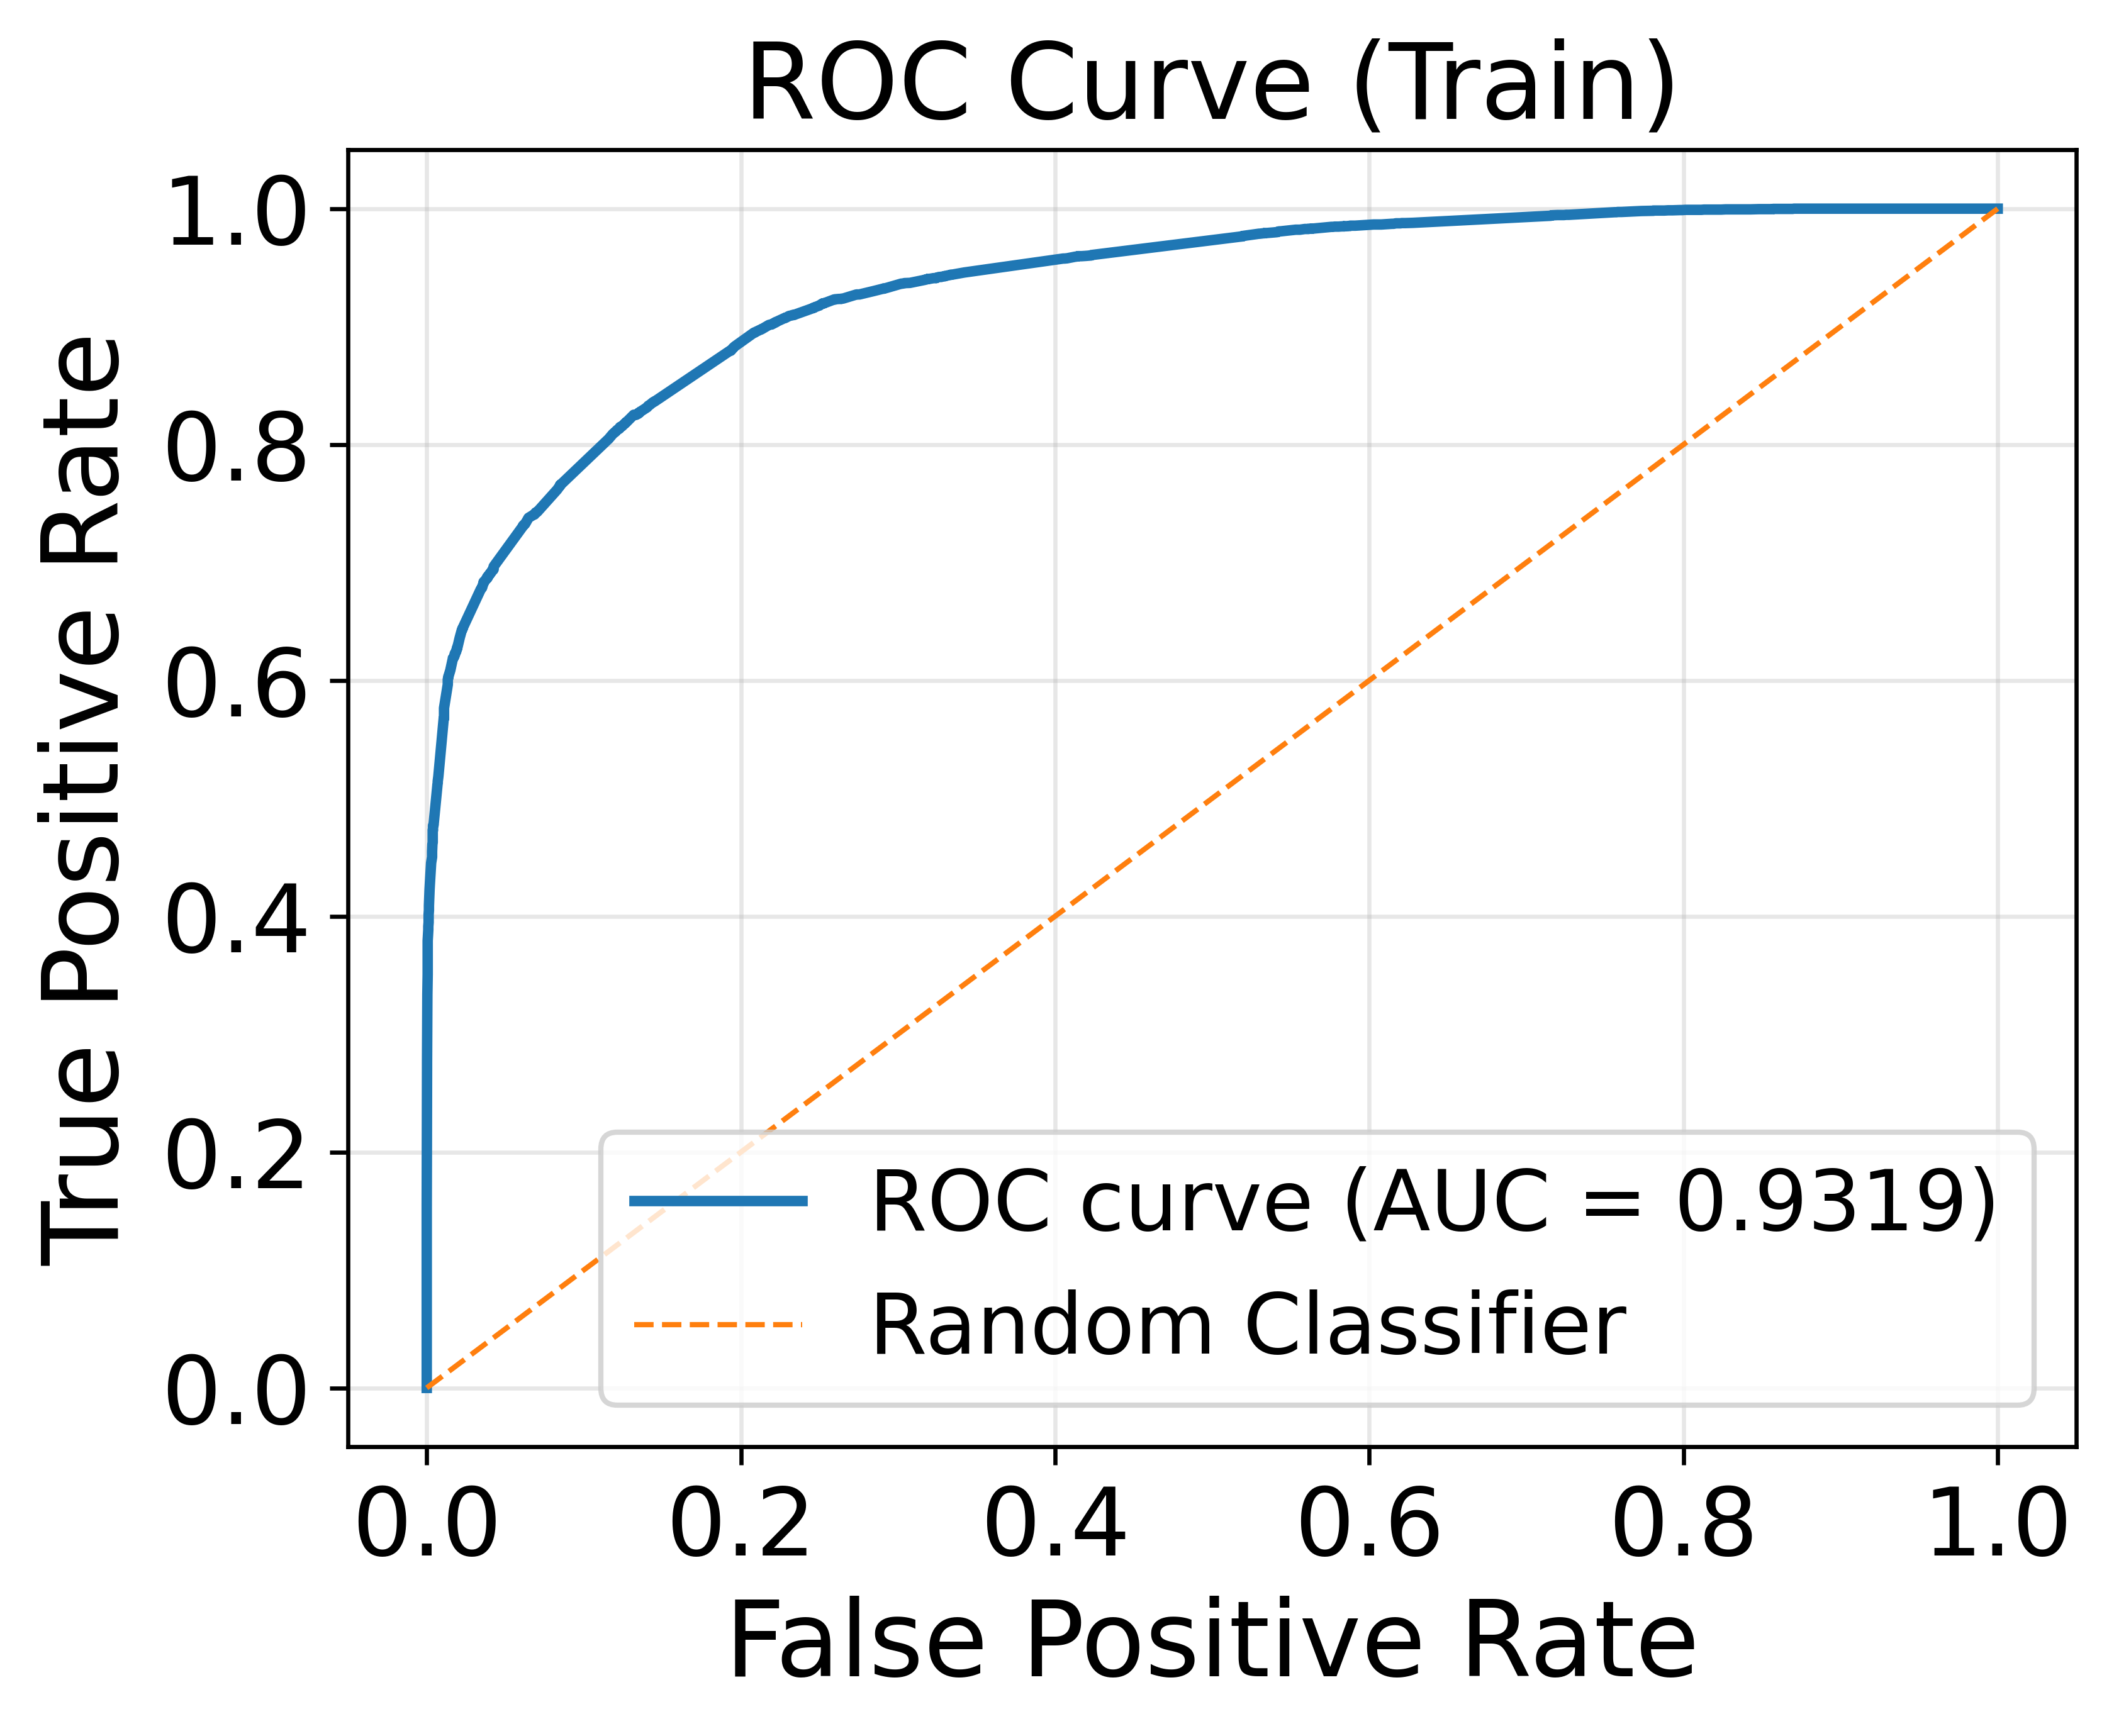


Evaluation Results: Validation
Accuracy  : 0.839794
Precision : 0.857283
Recall    : 0.814780
F1-score  : 0.835492
ROC AUC   : 0.913868
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.824000  0.864739  0.843878      1072
         1.0   0.857283  0.814780  0.835492      1069

    accuracy                       0.839794      2141
   macro avg   0.840642  0.839759  0.839685      2141
weighted avg   0.840618  0.839794  0.839691      2141



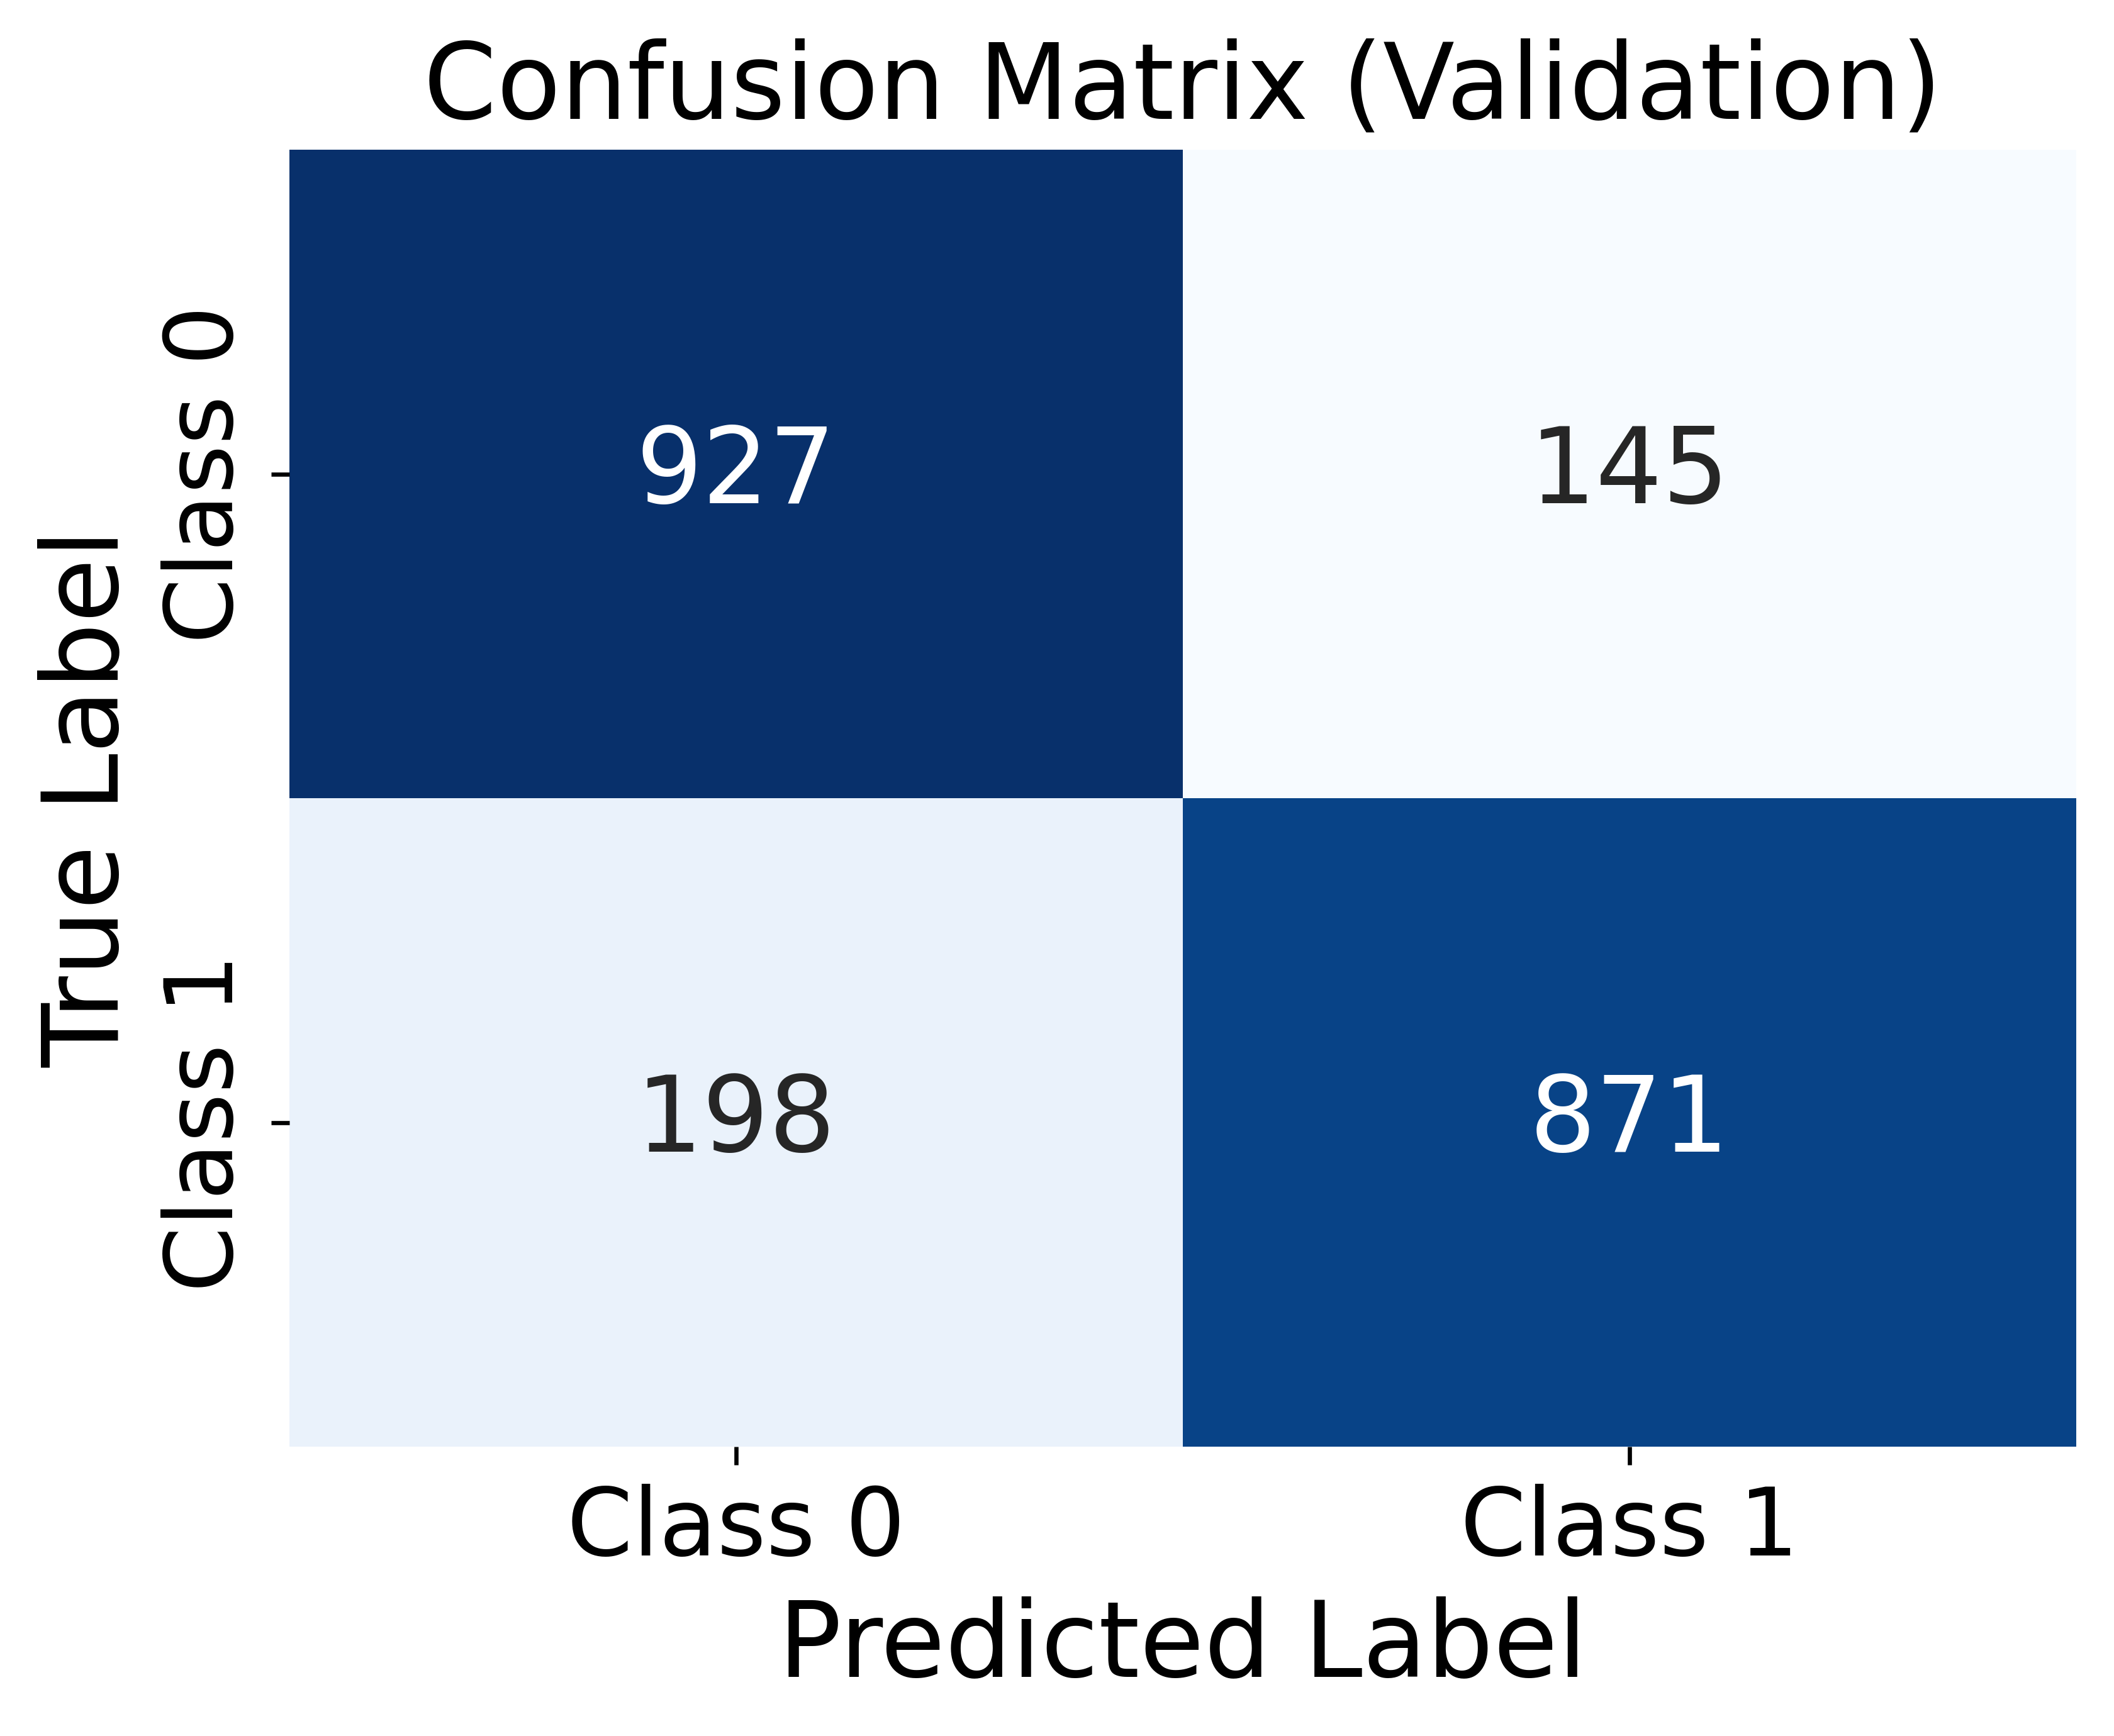

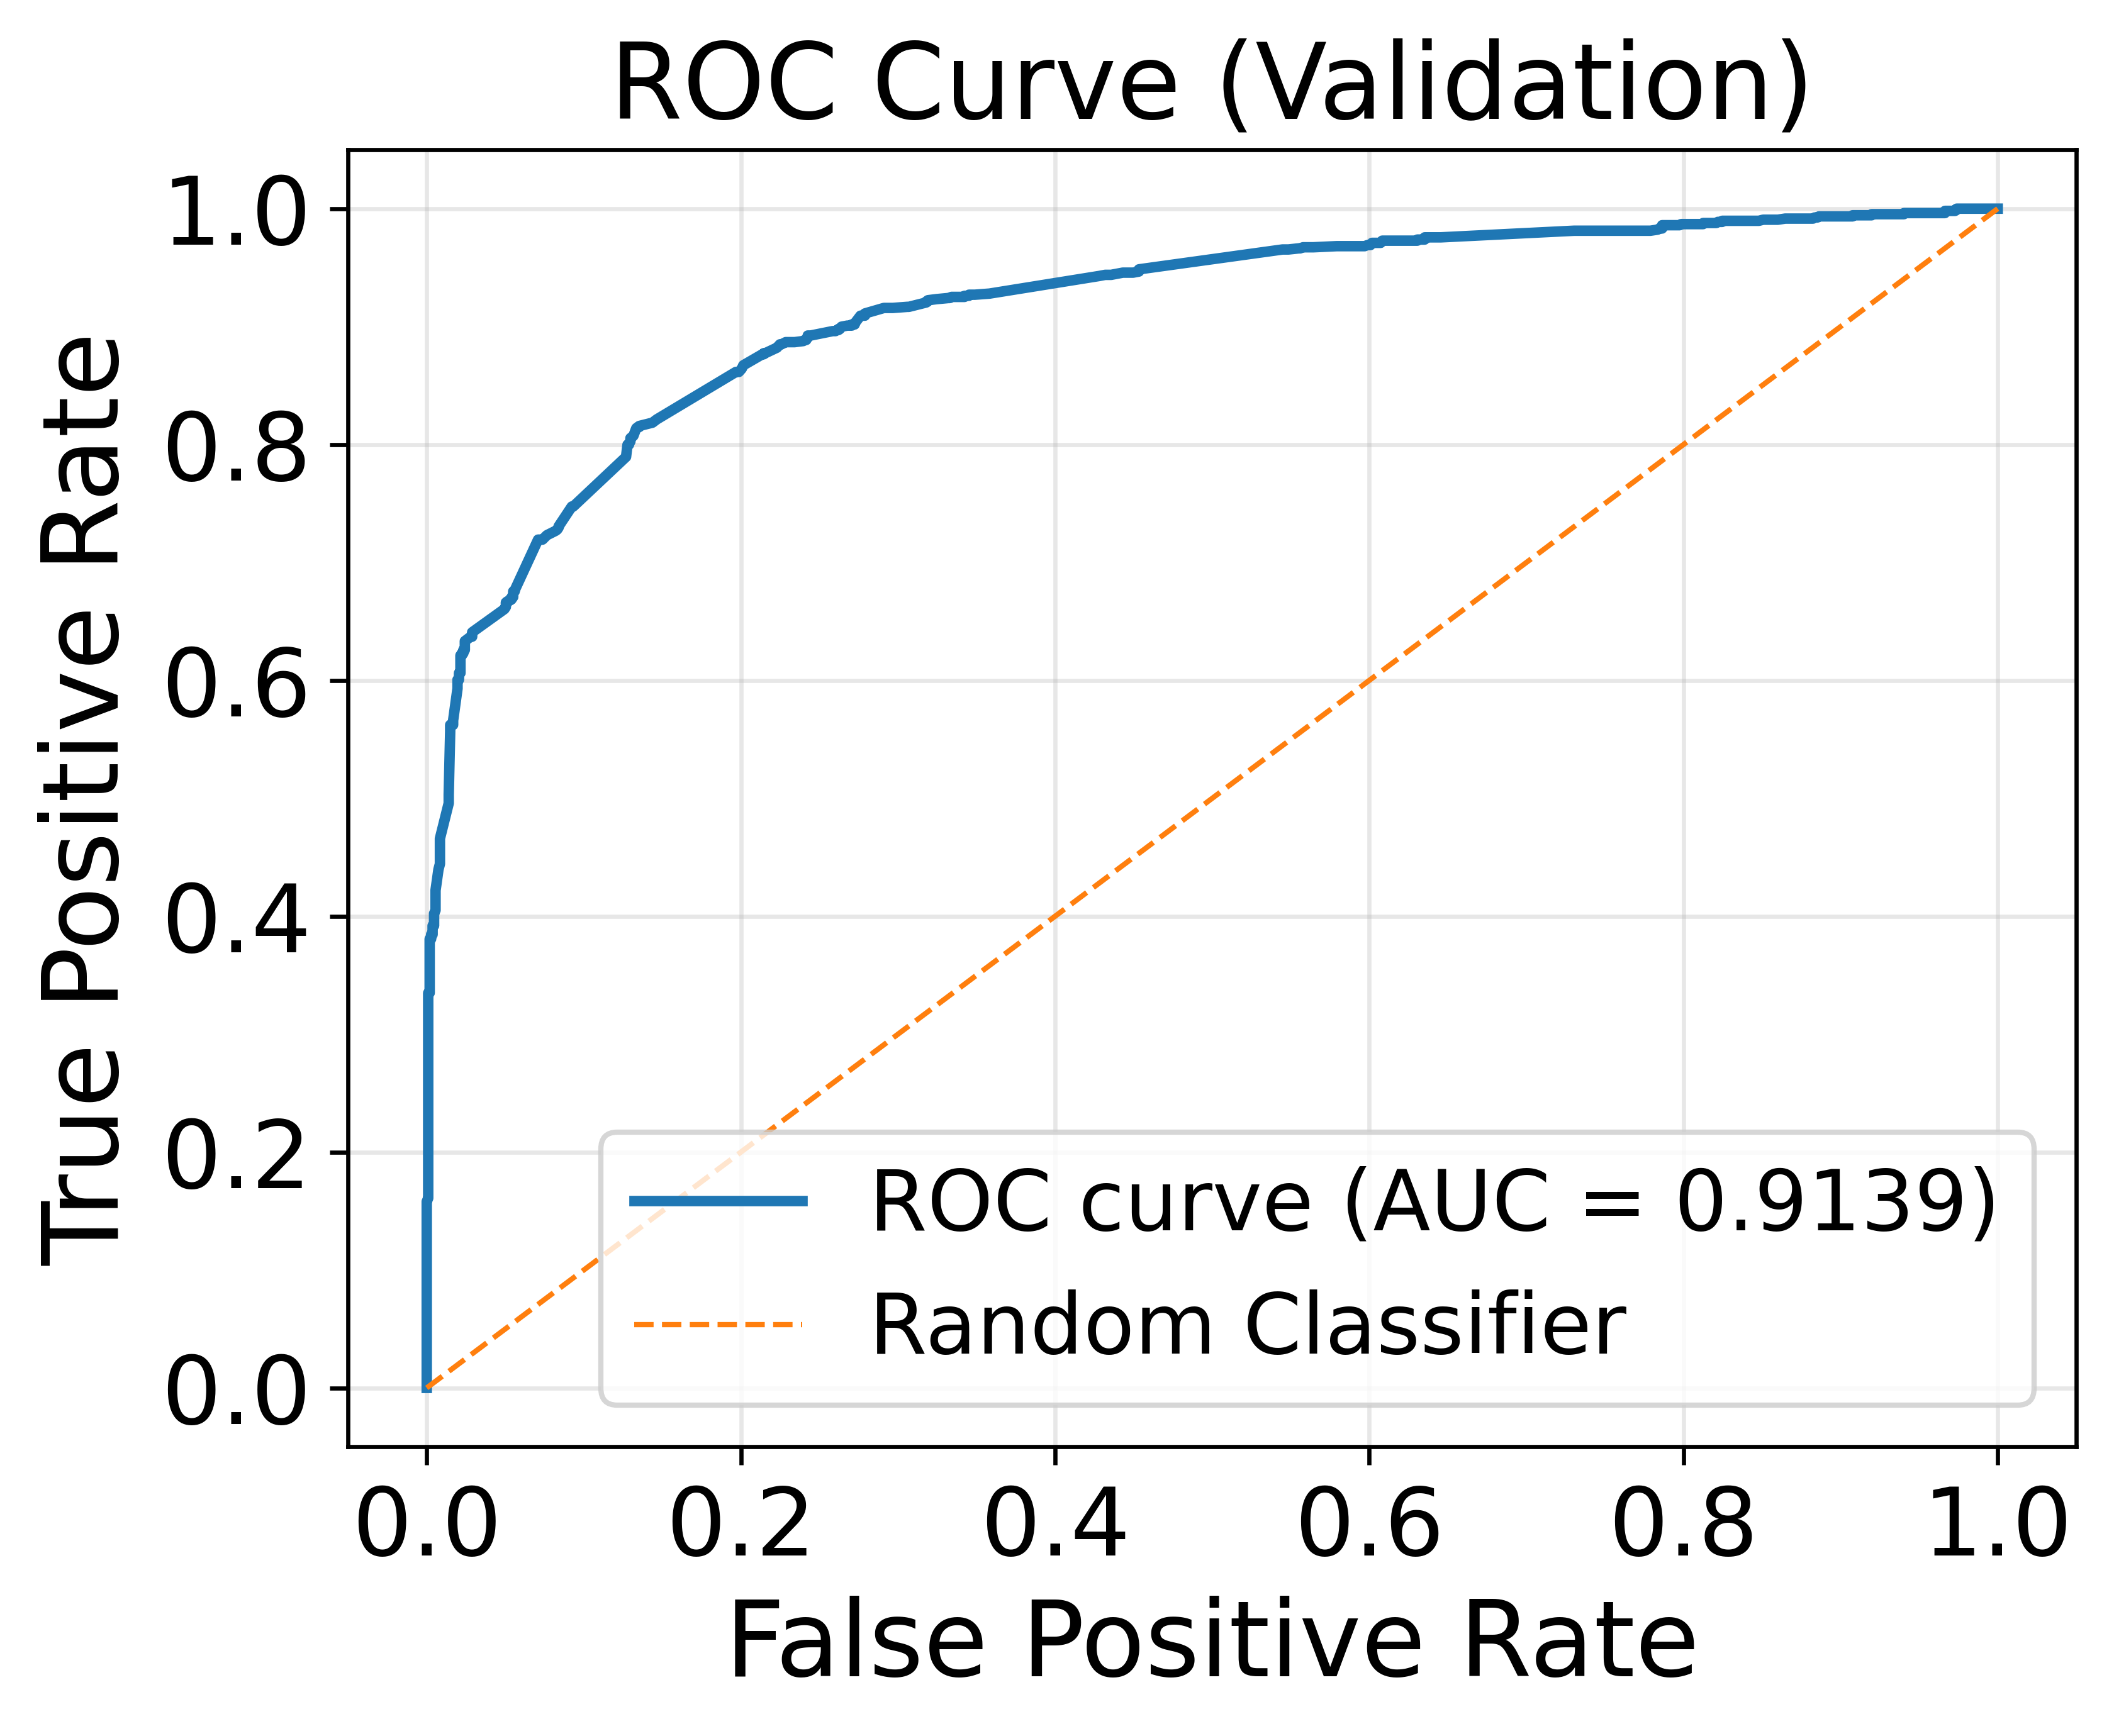


Evaluation Results: Test
Accuracy  : 0.844465
Precision : 0.850476
Recall    : 0.835360
F1-score  : 0.842850
ROC AUC   : 0.919432
----------------------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

         0.0   0.838680  0.853545  0.846047      1072
         1.0   0.850476  0.835360  0.842850      1069

    accuracy                       0.844465      2141
   macro avg   0.844578  0.844452  0.844449      2141
weighted avg   0.844570  0.844465  0.844451      2141



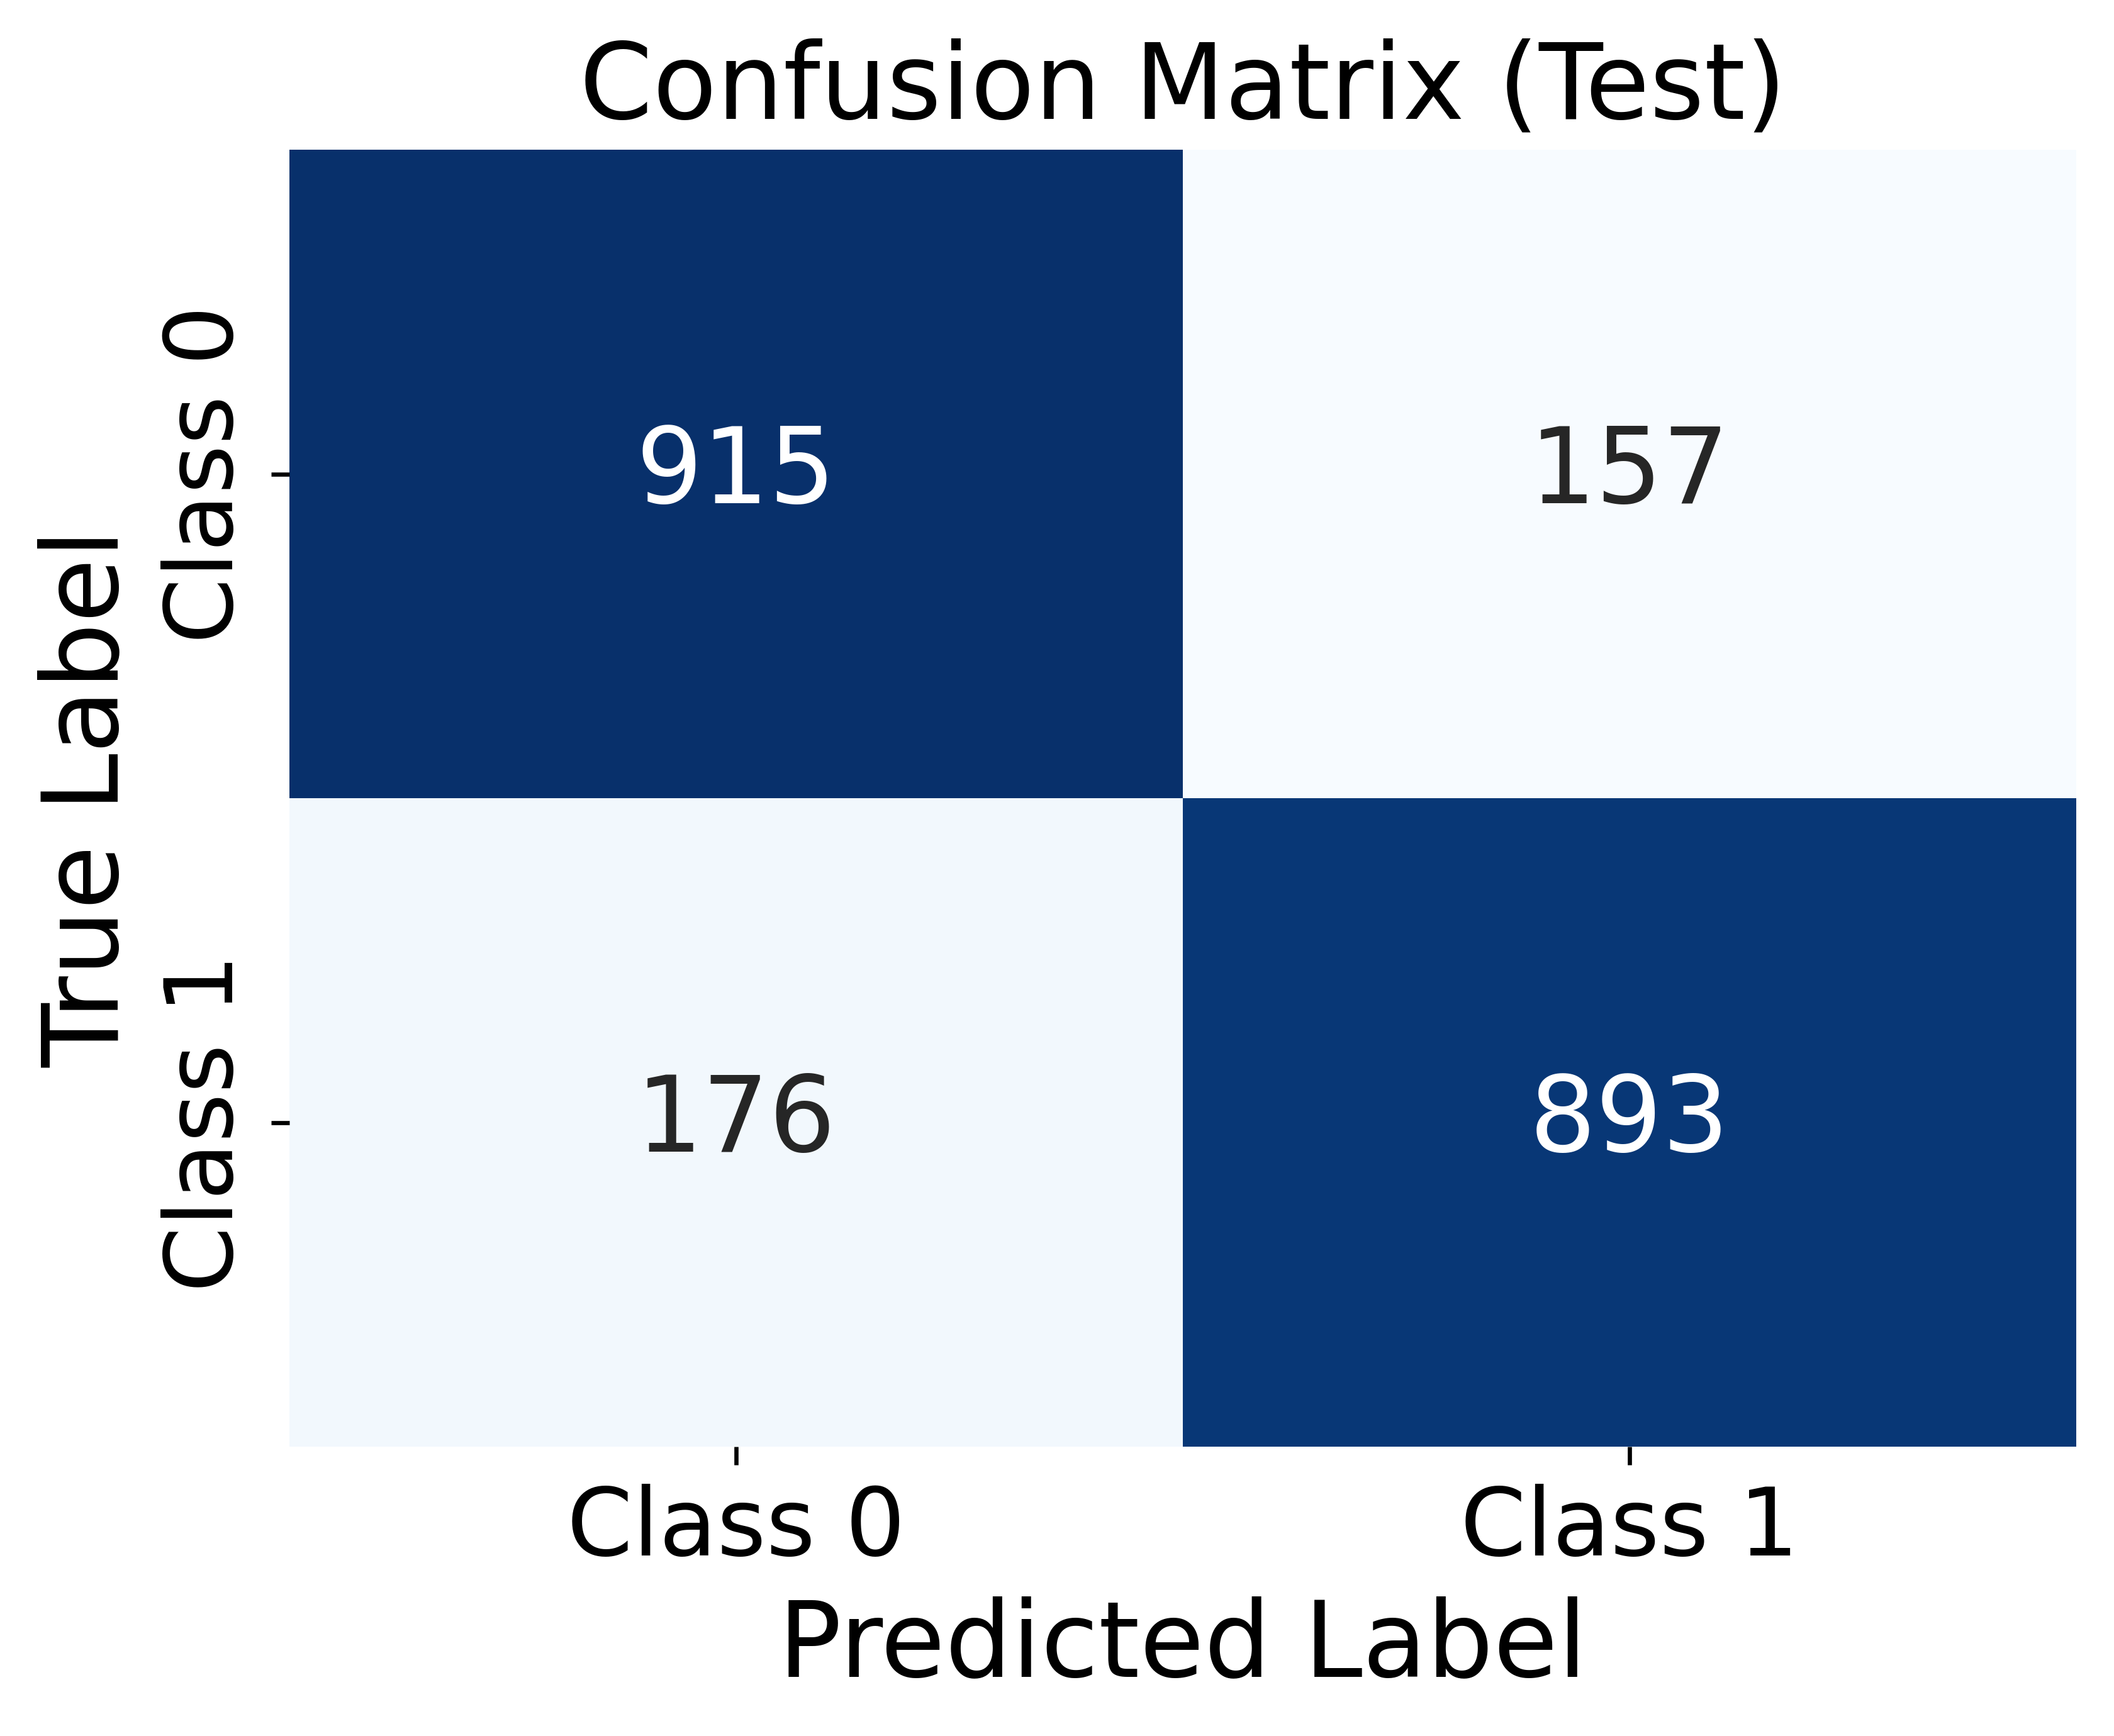

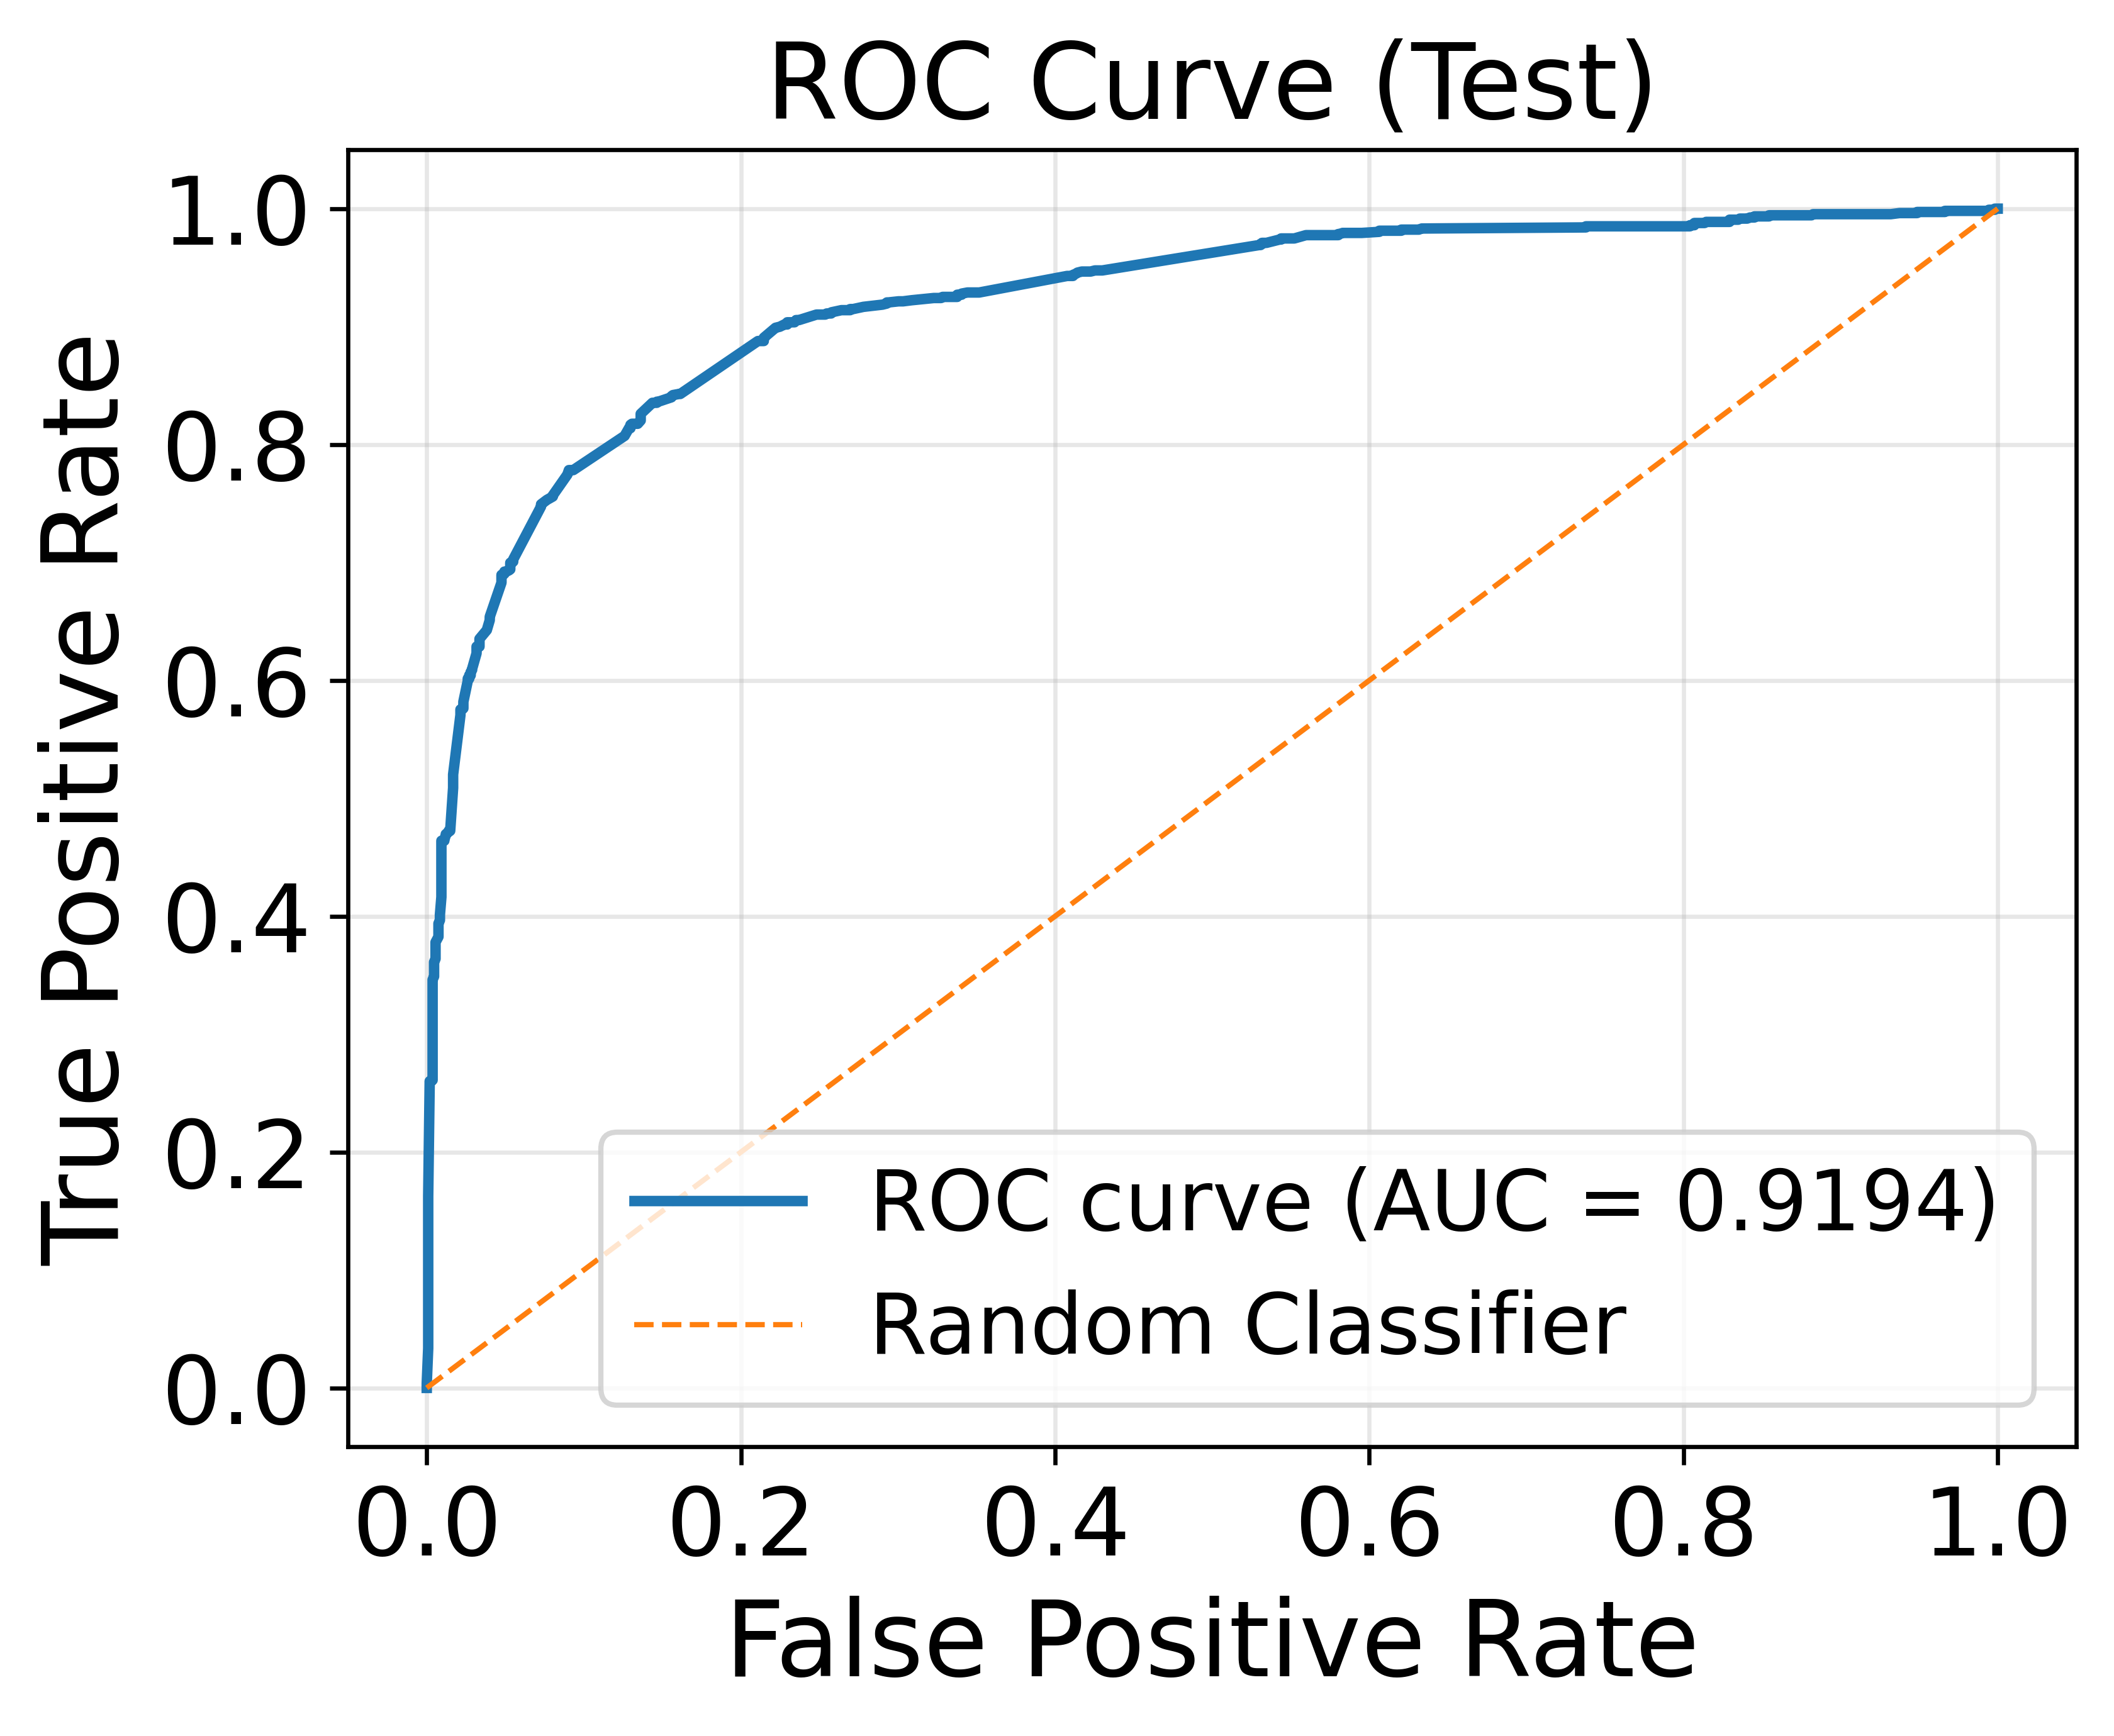

In [18]:
def evaluate_and_plot(model, X, y, dataset_name, output_dir=OUTPUT_DIR):
    """
    Evaluate the trained model on a given dataset and generate
    publication-quality confusion matrix and ROC curve figures.

    Parameters
    ----------
    model : keras.Model
        Trained classification model.
    X : np.ndarray or tensor-like
        Input feature matrix for evaluation.
    y : array-like
        Ground-truth labels.
    dataset_name : str
        Name of the dataset split (e.g., 'Train', 'Validation', 'Test').
    output_dir : str, optional
        Directory where evaluation figures will be saved.

    Returns
    -------
    results : dict
        Dictionary containing predictions and evaluation metrics.
    """

    # --------------------------------------------------------
    # Generate predictions
    # --------------------------------------------------------
    y_prob = model.predict(X, verbose=0).ravel()
    y_pred = (y_prob > 0.5).astype("int32")

    # --------------------------------------------------------
    # Compute evaluation metrics
    # --------------------------------------------------------
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)

    fpr, tpr, _ = roc_curve(y, y_prob)
    roc_auc = auc(fpr, tpr)

    cm = confusion_matrix(y, y_pred)
    report = classification_report(y, y_pred, digits=6)

    # --------------------------------------------------------
    # Print evaluation summary
    # --------------------------------------------------------
    print("\n" + "=" * 70)
    print(f"Evaluation Results: {dataset_name}")
    print("=" * 70)
    print(f"Accuracy  : {acc:.6f}")
    print(f"Precision : {prec:.6f}")
    print(f"Recall    : {rec:.6f}")
    print(f"F1-score  : {f1:.6f}")
    print(f"ROC AUC   : {roc_auc:.6f}")
    print("-" * 70)
    print("Classification Report:")
    print(report)

    # --------------------------------------------------------
    # Plot and save confusion matrix
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Class 0", "Class 1"],
        yticklabels=["Class 0", "Class 1"]
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix ({dataset_name})")
    plt.tight_layout()

    cm_png = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.png")
    cm_pdf = os.path.join(output_dir, f"confusion_matrix_{dataset_name.lower()}.pdf")
    plt.savefig(cm_png, dpi=600, bbox_inches="tight")
    plt.savefig(cm_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Plot and save ROC curve
    # --------------------------------------------------------
    plt.figure(figsize=(6, 5), dpi=600)
    plt.plot(fpr, tpr, linewidth=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1, label="Random Classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve ({dataset_name})")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    roc_png = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.png")
    roc_pdf = os.path.join(output_dir, f"roc_curve_{dataset_name.lower()}.pdf")
    plt.savefig(roc_png, dpi=600, bbox_inches="tight")
    plt.savefig(roc_pdf, bbox_inches="tight")
    plt.show()

    # --------------------------------------------------------
    # Return results for further analysis/reporting
    # --------------------------------------------------------
    results = {
        "dataset": dataset_name,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": np.array(y),
        "y_pred": y_pred,
        "y_prob": y_prob,
        "confusion_matrix_png": cm_png,
        "confusion_matrix_pdf": cm_pdf,
        "roc_curve_png": roc_png,
        "roc_curve_pdf": roc_pdf
    }

    return results


# ============================================================
# Evaluate on Training, Validation, and Test Sets
# ============================================================

train_results = evaluate_and_plot(model, X_train_pad, y_train, "Train")
val_results   = evaluate_and_plot(model, X_val_pad, y_val, "Validation")
test_results  = evaluate_and_plot(model, X_test_pad, y_test, "Test")

### Save All Results

In [19]:
# ------------------------------------------------------------
# Create summary DataFrame
# ------------------------------------------------------------
summary_df = pd.DataFrame([
    {
        "Dataset": train_results["dataset"],
        "Accuracy": train_results["accuracy"],
        "Precision": train_results["precision"],
        "Recall": train_results["recall"],
        "F1-score": train_results["f1_score"],
        "ROC AUC": train_results["roc_auc"]
    },
    {
        "Dataset": val_results["dataset"],
        "Accuracy": val_results["accuracy"],
        "Precision": val_results["precision"],
        "Recall": val_results["recall"],
        "F1-score": val_results["f1_score"],
        "ROC AUC": val_results["roc_auc"]
    },
    {
        "Dataset": test_results["dataset"],
        "Accuracy": test_results["accuracy"],
        "Precision": test_results["precision"],
        "Recall": test_results["recall"],
        "F1-score": test_results["f1_score"],
        "ROC AUC": test_results["roc_auc"]
    }
])

# ------------------------------------------------------------
# Define save paths
# ------------------------------------------------------------
csv_path  = os.path.join(OUTPUT_DIR, "evaluation_summary.csv")
xlsx_path = os.path.join(OUTPUT_DIR, "evaluation_summary.xlsx")

# ------------------------------------------------------------
# Save files
# ------------------------------------------------------------
summary_df.to_csv(csv_path, index=False)
summary_df.to_excel(xlsx_path, index=False)

# ------------------------------------------------------------
# Confirmation
# ------------------------------------------------------------
print("=" * 60)
print("Evaluation summary saved successfully:")
print(f"CSV  : {csv_path}")
print(f"Excel: {xlsx_path}")
print("=" * 60)

# Display table
summary_df

Evaluation summary saved successfully:
CSV  : Evaluation_Outputs_Pattern_PSO_Attention_Transformer/evaluation_summary.csv
Excel: Evaluation_Outputs_Pattern_PSO_Attention_Transformer/evaluation_summary.xlsx


,Dataset,Accuracy,Precision,Recall,F1-score,ROC AUC
0,Train,0.845830,0.859496,0.826418,0.842632,0.931865
1,Validation,0.839794,0.857283,0.814780,0.835492,0.913868
2,Test,0.844465,0.850476,0.835360,0.842850,0.919432


### Clear Final Backend Session

In [20]:
# ============================================================
# Memory Management and Session Reset
# ============================================================

# Trigger garbage collection to free unused memory
gc.collect()

# Clear the current TensorFlow/Keras session to release GPU/CPU resources
# This is particularly important when training multiple models sequentially
tf.keras.backend.clear_session()